# GEEANNT version 0.7.2

Starting back creating an organized python package

After passing u_v and u_r in the model via quantile transformation to reduce the input file size, we now want to pass phi_v and phi_r quantile transformed, removing sine and cosine and reducing the parameters from 7 to 5

In [1]:
# ==========================================================
# Imports
# ==========================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # reduce TensorFlow log verbosity

import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing

import scipy.stats as st
from scipy.stats import chi2, norm, ks_2samp, wasserstein_distance
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import c, m_e

from astropy.stats import poisson_conf_interval

from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D

# Hyperparameter optimization
import optuna

# ==========================================================
# TensorFlow / Keras
# Force CPU for this project, since it is faster than tf-metal
# for this specific custom CVAE on the M1 MacBook Air
# ==========================================================
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

from tensorflow import keras
from tensorflow.keras import layers
from keras import regularizers

# ==========================================================
# Version / device checks
# ==========================================================
print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)

print("\nPhysical devices  :", tf.config.list_physical_devices())
print("Physical GPU(s)   :", tf.config.list_physical_devices("GPU"))

print("\nLogical devices   :", tf.config.list_logical_devices())
print("Logical GPU(s)    :", tf.config.list_logical_devices("GPU"))

TensorFlow version: 2.16.2
Keras version     : 3.12.1

Physical devices  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical GPU(s)   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Logical devices   : [LogicalDevice(name='/device:CPU:0', device_type='CPU')]
Logical GPU(s)    : []


In [2]:
import GEEANNT as ge
print(ge.__file__)
print(ge.__version__)
print(ge.CVAE_CatEnergy_CatUV)
print(ge.CVAE_CatEnergy_CatUV_TaskAdaptive)

ge.initialize_environment(seed=42)


/Volumes/X10Pro/MAGI/GEEANNT_package/GEEANNT/__init__.py
0.7.2
<class 'GEEANNT.core.model.CVAE_CatEnergy_CatUV'>
<class 'GEEANNT.core.model.CVAE_CatEnergy_CatUV_TaskAdaptive'>


## Dataset Import and Checks

In [11]:
df = ge.load_detector_table(
    filepath="/Volumes/X10Pro/MAGI/TrainingData/alloutputDSCryoSphereCR.dat",
    sep=r"\s+",
)

center = (0.0, 0.0, -507.66)
R = 100.0

ge.report_basic_table_checks(df)

prep = ge.build_physical_features(
    df,
    center=center,
    radius=R,
)

ge.print_physical_summary(prep)

# Base diagnostic objects
feat_base = prep["features"]
raw = prep["raw"]
proj = prep["projected"]
normdir = prep["normalized_direction"]
derived = prep["derived"]

# ==========================================================
# v0.7.2 feature dataframe:
#   u_r   -> QuantileTransformer
#   u_v   -> QuantileTransformer
#   phi_r -> QuantileTransformer
#   phi_v -> QuantileTransformer
#
# Final continuous model variables:
#   [u_r_q, u_v_q, phi_r_q, phi_v_q]
# ==========================================================

feature_pack = ge.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    n_bins=512,
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=512,
    random_state=42,
)

ge.report_feature_dataframe(feature_pack)

feat = feature_pack["feat"]
energy_bins = feature_pack["energy_bins"]
n_energy_bins = feature_pack["n_energy_bins"]

quantile_transformers = feature_pack["quantile_transformers"]
geometry_metadata = feature_pack["geometry_metadata"]

qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]

print("Feature columns:", feat.columns.tolist())
print("Geometry metadata:", geometry_metadata)

N rows: 3443885
  ParticleName      Energy        X        Y        Z        Vx        Vy  \
0        gamma    0.367431  53.2306 -72.7807 -548.471  0.201221  0.958547   
1          mu-  716.273000 -25.0220  88.2329 -544.881  0.705749 -0.707037   
2        gamma    0.739842  53.3597  58.3337 -448.010 -0.280581  0.182790   
3    anti_nu_e   23.225500  46.3443  10.0797 -420.700 -0.093070  0.222552   
4        gamma    0.263092  64.1741 -67.0382 -542.076 -0.997532 -0.061041   

         Vz  
0 -0.201739  
1 -0.044910  
2 -0.942264  
3 -0.970468  
4 -0.034698  

NaN per column:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64

--- RAW sphere check ---
r: mean = 99.12126741081232 std = 0.2926107376125263 min = 98.93974421814974 max = 100.0601790229645
Mean absolute deviation from R: 0.8798800962455824

--- RAW direction norm check ---
||v||: mean = 1.000000000151691 std = 2.8860505175

In [83]:
ge.set_plot_theme("light")

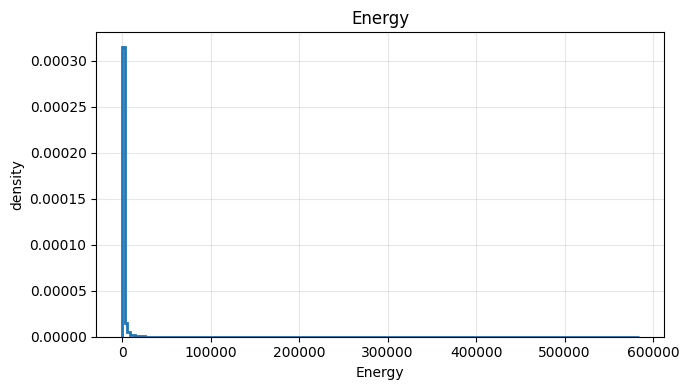

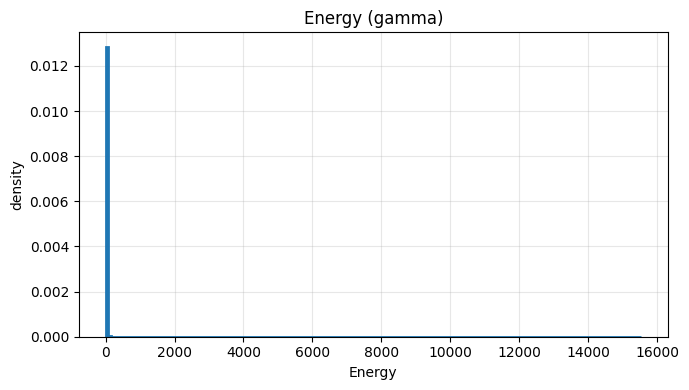

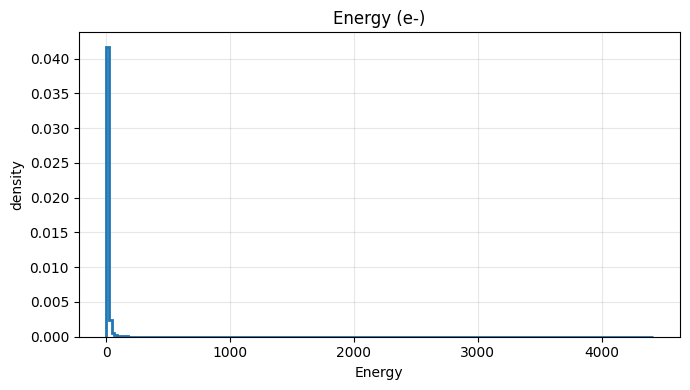

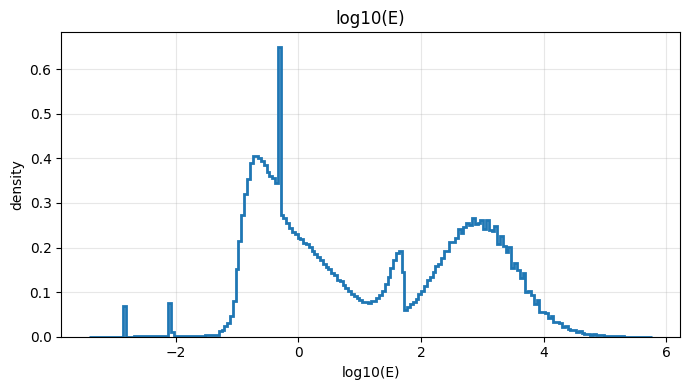

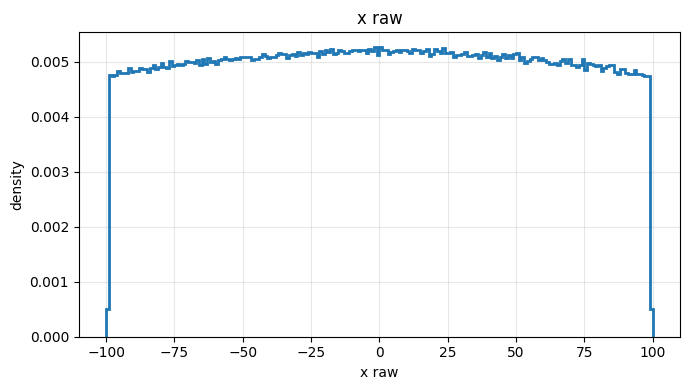

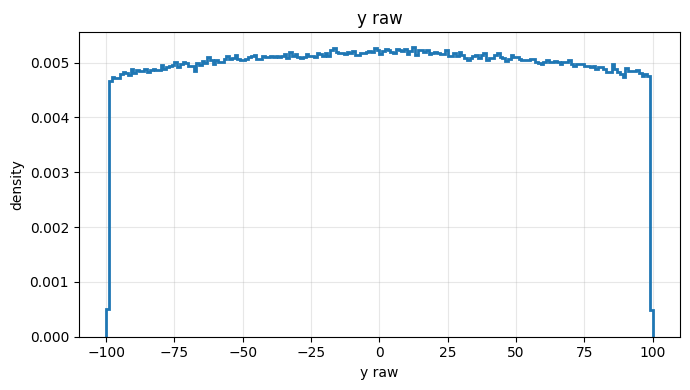

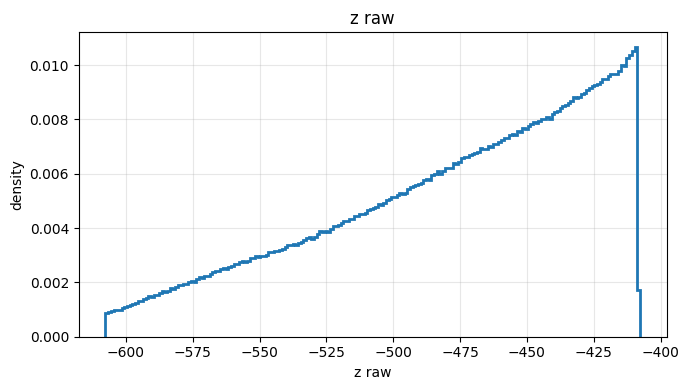

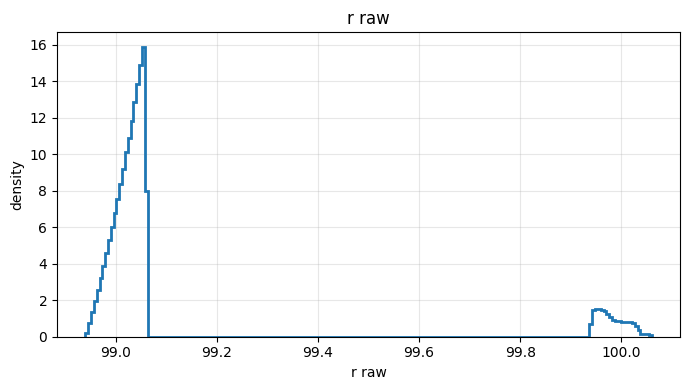

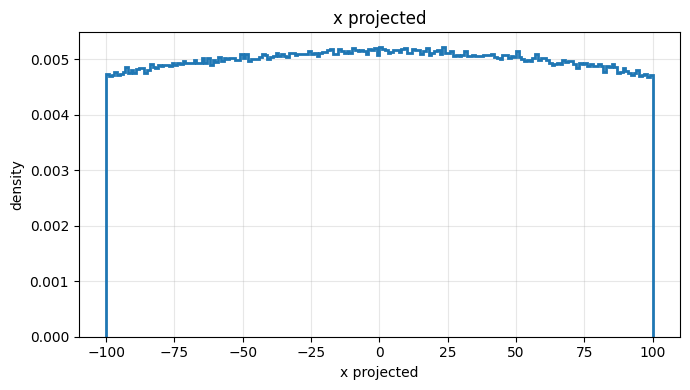

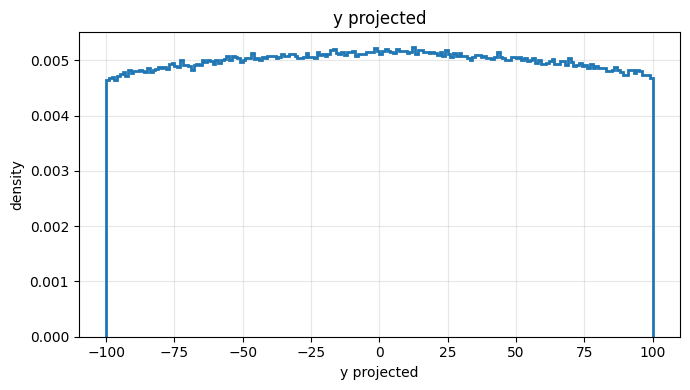

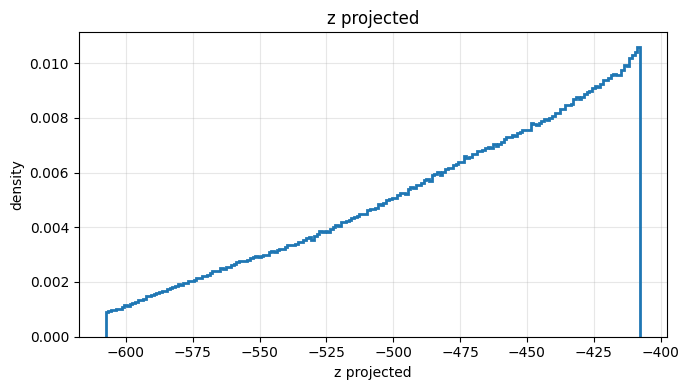

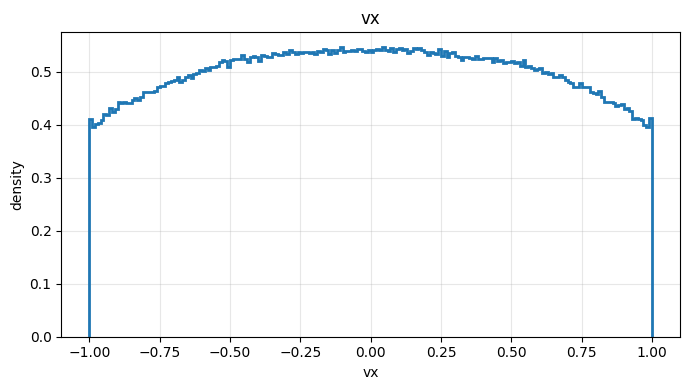

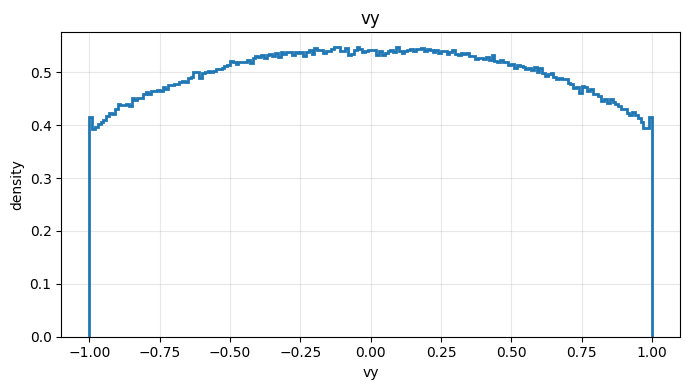

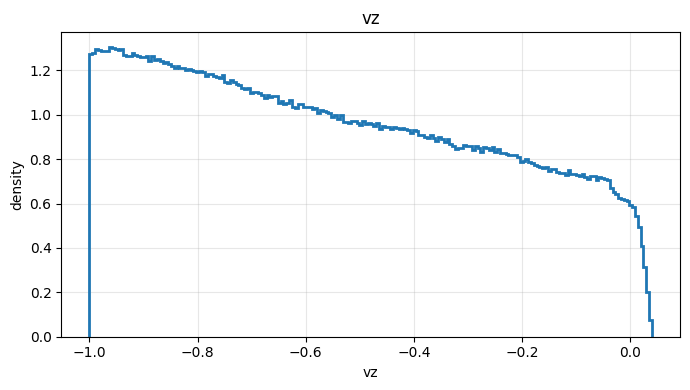

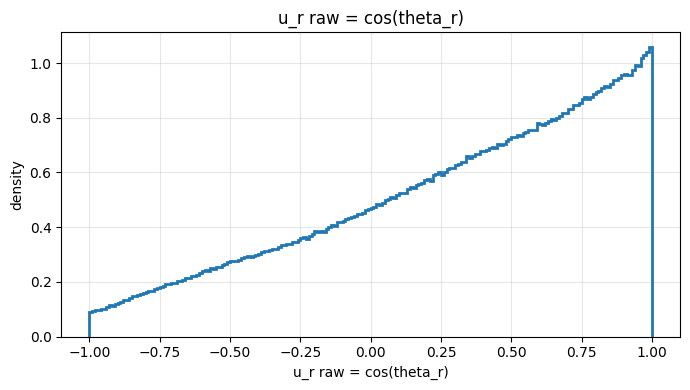

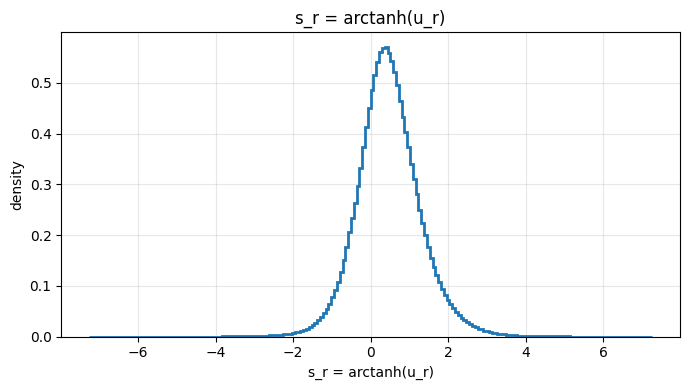

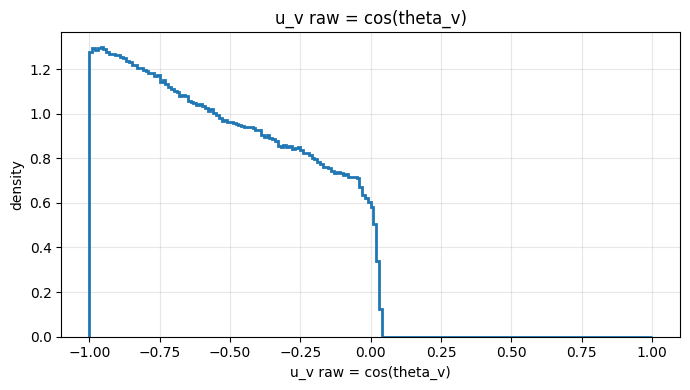

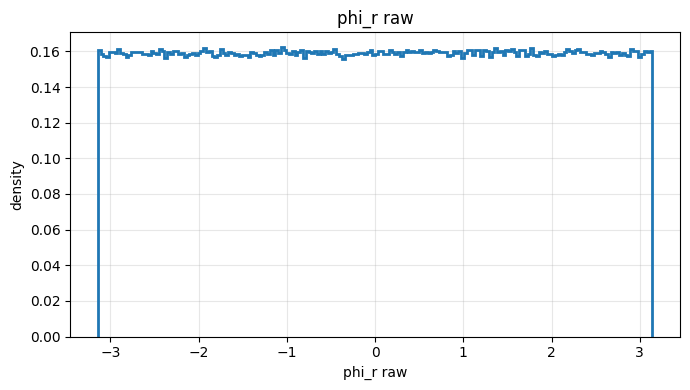

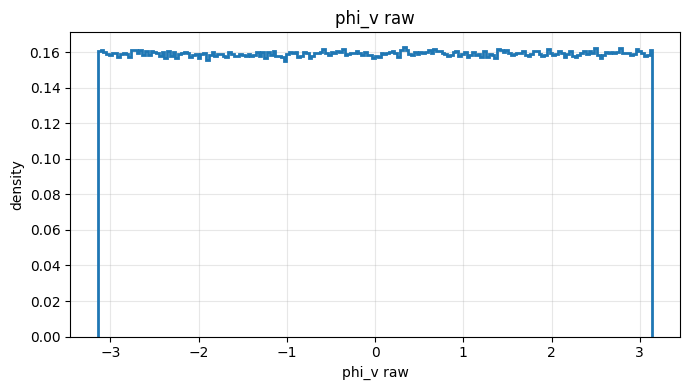

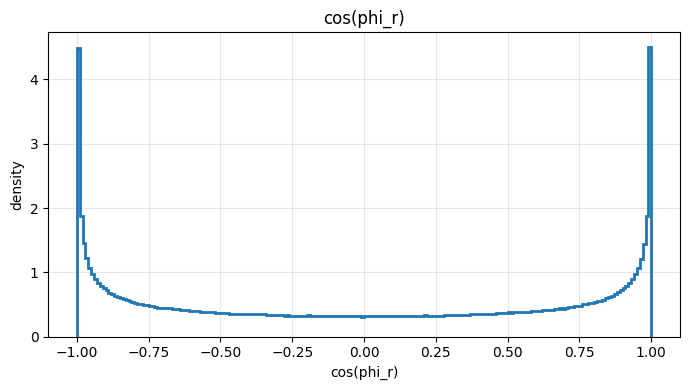

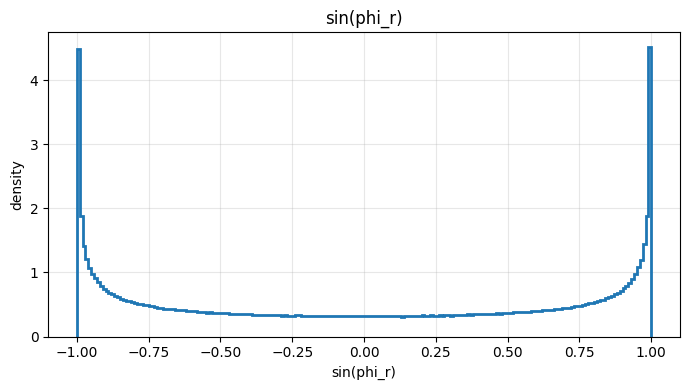

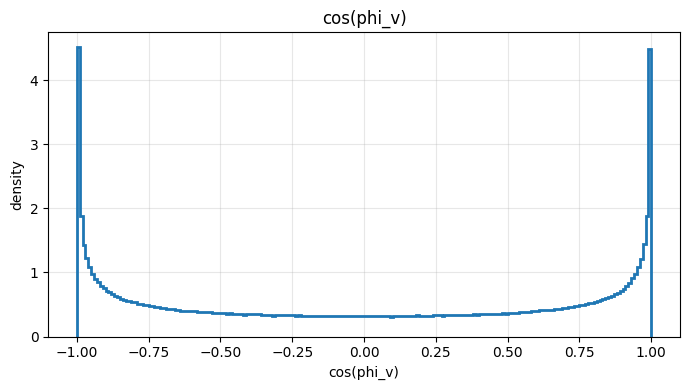

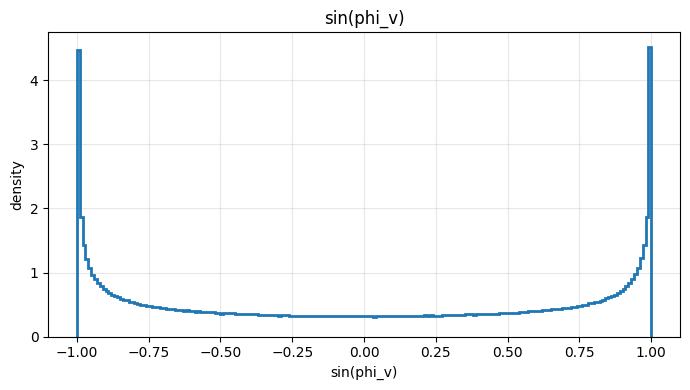

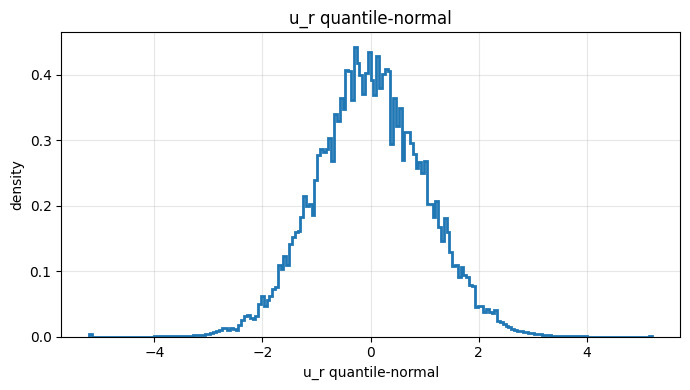

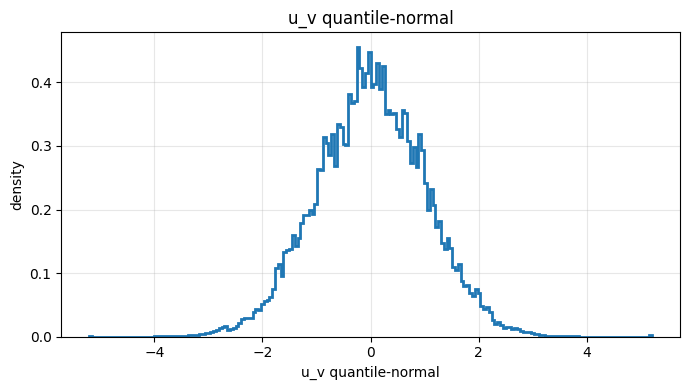

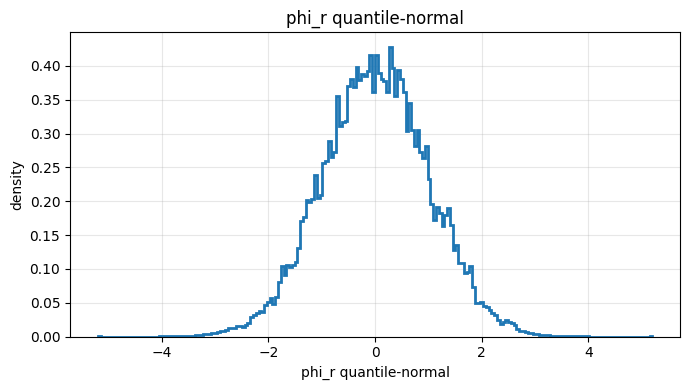

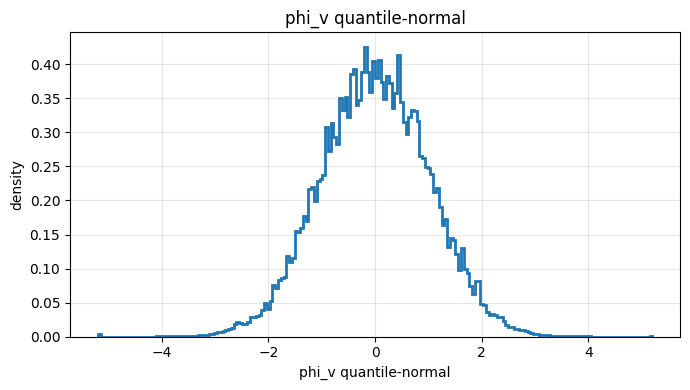

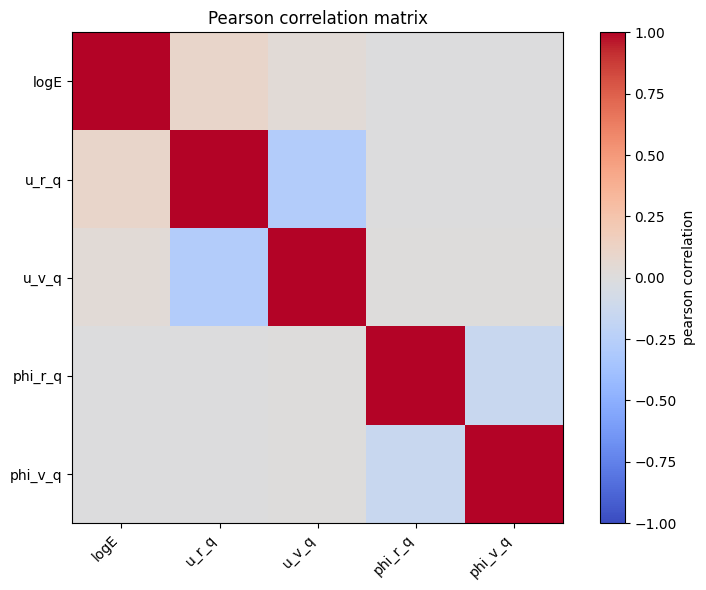

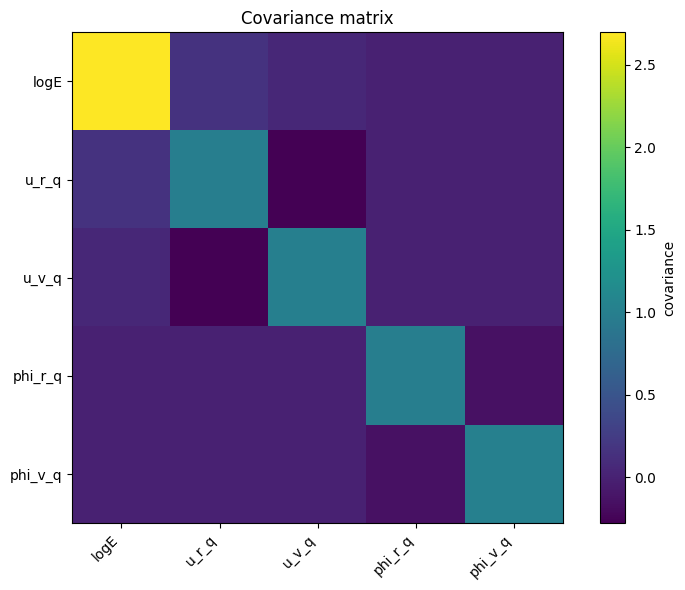

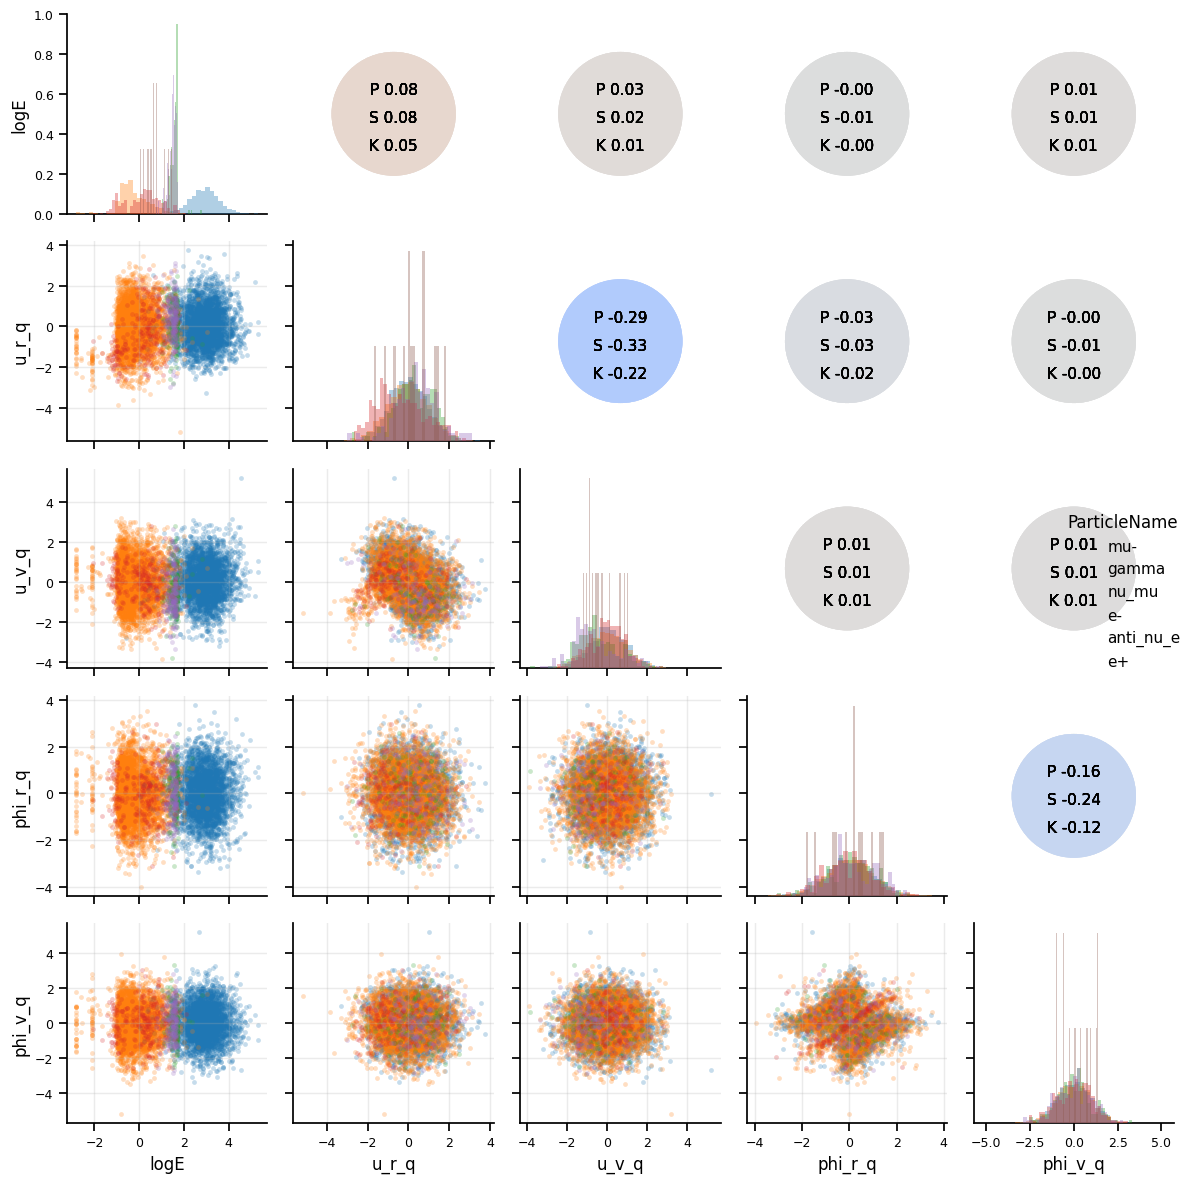

In [12]:
# ==========================================================
# Energy diagnostics from base physical features
# ==========================================================

ge.plot_dist(feat_base["Energy"], "Energy")
ge.plot_dist_by_class(feat_base, "Energy", selected_class="gamma")
ge.plot_dist_by_class(feat_base, "Energy", selected_class="e-")
ge.plot_dist(feat_base["logE"], "log10(E)")

# ==========================================================
# Raw / projected geometry
# ==========================================================

ge.plot_dist(raw["x"], "x raw")
ge.plot_dist(raw["y"], "y raw")
ge.plot_dist(raw["z"], "z raw")
ge.plot_dist(raw["r"], "r raw")

ge.plot_dist(proj["x"], "x projected")
ge.plot_dist(proj["y"], "y projected")
ge.plot_dist(proj["z"], "z projected")

# ==========================================================
# Direction diagnostics
# ==========================================================

ge.plot_dist(normdir["vx"], "vx")
ge.plot_dist(normdir["vy"], "vy")
ge.plot_dist(normdir["vz"], "vz")

# ==========================================================
# Raw physical geometry variables
# ==========================================================

ge.plot_dist(feat_base["u_r"], "u_r raw = cos(theta_r)", range_=(-1, 1))
ge.plot_dist(feat_base["s_r"], "s_r = arctanh(u_r)")
ge.plot_dist(feat_base["u_v"], "u_v raw = cos(theta_v)", range_=(-1, 1))

ge.plot_dist(feat_base["phi_r"], "phi_r raw", range_=(-np.pi, np.pi))
ge.plot_dist(feat_base["phi_v"], "phi_v raw", range_=(-np.pi, np.pi))

# Optional: inspect original cos/sin diagnostics from base features
ge.plot_dist(feat_base["cphi_r"], "cos(phi_r)", range_=(-1, 1))
ge.plot_dist(feat_base["sphi_r"], "sin(phi_r)", range_=(-1, 1))
ge.plot_dist(feat_base["cphi_v"], "cos(phi_v)", range_=(-1, 1))
ge.plot_dist(feat_base["sphi_v"], "sin(phi_v)", range_=(-1, 1))

# ==========================================================
# v0.7.2 quantile-normal variables
# ==========================================================

ge.plot_dist(feat["u_r_q"], "u_r quantile-normal")
ge.plot_dist(feat["u_v_q"], "u_v quantile-normal")
ge.plot_dist(feat["phi_r_q"], "phi_r quantile-normal")
ge.plot_dist(feat["phi_v_q"], "phi_v quantile-normal")

# ==========================================================
# Correlation / covariance matrix for v0.7.2 features
# ==========================================================

corr_df = feat.copy()
corr_df["logE"] = (
    feat_base
    .loc[feature_pack["mask_energy"], "logE"]
    .reset_index(drop=True)
)

corr_cols = [
    "logE",
    "u_r_q",
    "u_v_q",
    "phi_r_q",
    "phi_v_q",
]

corr = ge.plot_correlation_matrix(
    corr_df,
    corr_cols,
    method="pearson",
)

cov = ge.plot_covariance_matrix(
    corr_df,
    corr_cols,
)

# ==========================================================
# Pairgrid for v0.7.2
# ==========================================================

ge.plot_pairgrid_physics(
    corr_df,
    cols=corr_cols,
    class_col="ParticleName",
    sample_size=8000,
    lower_mode="scatter",
    bins=30,
    contour_levels=8,
    figsize_scale=2.4,
    theme="light",
    palette="tab10",
)

plt.show()

In [13]:
'''feature_pack = ge.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    e_min_cut=0.05,
    e_max_cut=0.8,
    bin_width=0.500,
    n_bins=256,
    min_counts=20,

    # v0.7.2
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=10000,
    random_state=42,
)'''

# Feature pack for CRs

feature_pack = ge.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    #e_min_cut=0.05,
    #e_max_cut=0.8,
    n_bins=256,
    min_counts=100,

    # v0.7.2
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=10000,
    random_state=42,
)

ge.report_feature_dataframe(feature_pack)

feat = feature_pack["feat"]

energy_bins = feature_pack["energy_bins"]
n_energy_bins = feature_pack["n_energy_bins"]

prep = feature_pack["filtered_prep"]

# Quantile transformers
quantile_transformers = feature_pack["quantile_transformers"]

qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]

geometry_metadata = feature_pack["geometry_metadata"]

print("Feature columns:", feat.columns.tolist())
print(geometry_metadata)


feat shape: (3443885, 6)
geometry_transform: quantile_u_r_u_v_phi_r_phi_v

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q
0        gamma     82 -1.197646  0.980098 -0.377857  0.582957
1          mu-    174 -1.144044  1.709177  0.820844 -0.336785
2        gamma     91  0.343266 -1.461600  0.343946  1.330176
3    anti_nu_e    133  1.178254 -1.766368  0.092314  0.894929
4        gamma     78 -1.100084  1.795517 -0.323269 -2.385135

--- Finite check ---
Rows with NaN/Inf: 0

--- Feature ranges ---
     E_idx : 0  255
     u_r_q : -5.199337482452393  5.199337482452393
     u_v_q : -5.199337482452393  5.199337482452393
   phi_r_q : -5.199337482452393  5.199337482452393
   phi_v_q : -5.199337482452393  5.199337482452393

--- Quantile geometry checks ---
u_r_q: mean = -0.000545, std = 0.996885, min = -5.199337, max = 5.199337
u_v_q: mean = 0.002369, std = 1.006195, min = -5.199337, max = 5.199337
phi_r_q: mean = 0.006944, std = 0.999884, min = -5.199337, max = 5.199

## Standardization and Preprocessing

Dataset mode: continuous_geometry
Continuous geometry version: v0.7.2_continuous_phi
Kept particle types: 6
Types: ['gamma', 'mu-', 'e-', 'anti_nu_e', 'nu_mu', 'e+']

Empirical probabilities:
       gamma  p=5.032918e-01
         mu-  p=4.172242e-01
          e-  p=3.211547e-02
   anti_nu_e  p=2.303271e-02
       nu_mu  p=2.300193e-02
          e+  p=1.333959e-03

Shapes:
X_cont_raw: (3443885, 4)
E_idx     : (3443885,)
y_type    : (3443885,)

--- Continuous feature ranges ---
   u_r_q : -5.199337482452393  5.199337482452393
   u_v_q : -5.199337482452393  5.199337482452393
 phi_r_q : -5.199337482452393  5.199337482452393
 phi_v_q : -5.199337482452393  5.199337482452393

--- Continuous means/std ---
   u_r_q : mean=-0.000545  std= 0.996885
   u_v_q : mean= 0.002369  std= 1.006195
 phi_r_q : mean= 0.006944  std= 0.999884
 phi_v_q : mean=-0.003849  std= 1.010336

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q
0        gamma     82 -1.197646  0.980098 -0.377857  0

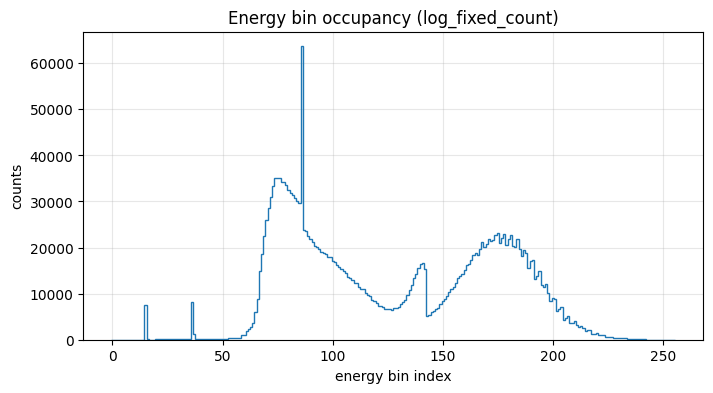

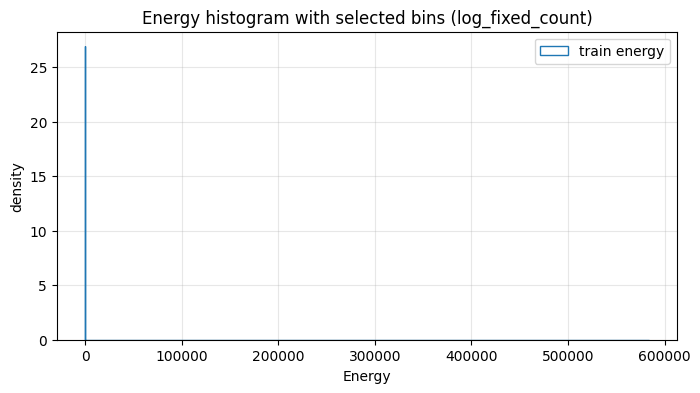

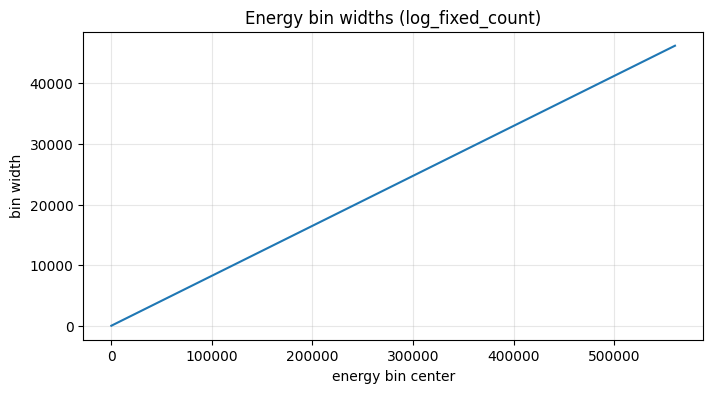

In [14]:
dataset_pack = ge.filter_particle_types_continuous_geometry(
    feat=feature_pack["feat"],
    prob_threshold=1e-5,
    cont_cols=("u_r_q", "u_v_q", "phi_r_q", "phi_v_q"),
)

ge.report_continuous_geometry_features(dataset_pack)

split_pack = ge.split_feature_data(
    dataset_pack,
    test_size_total=0.30,
    val_size_from_temp=0.50,
    random_state=42,
)

ge.report_split_summary(split_pack, n_types=dataset_pack["n_types"])

scaled_pack = ge.scale_continuous_features(
    split_pack,
    scale_cols=(),
)

ge.report_scaled_features(scaled_pack)

condition_pack = ge.build_conditioning_and_weights(
    scaled_pack,
    n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"],
    alpha=0.5,
)

ge.report_conditioning(condition_pack, n_types=dataset_pack["n_types"])

tf_pack = ge.build_tf_datasets(
    condition_pack,
    batch_size=4096,
    shuffle_buffer_cap=200_000,
)

ge.report_tf_datasets(tf_pack)

ge.report_energy_binning_diagnostics(
    energy_bins=feature_pack["energy_bins"],
    E_idx=dataset_pack["E_idx"],
    E_values=feature_pack["filtered_prep"]["features"]["Energy"].to_numpy(),
    idx_train=split_pack["idx_train"],
    energy_binning_mode=feature_pack["energy_config"]["mode"],
    bin_width=feature_pack["energy_config"]["bin_width"],
    n_bins=feature_pack["energy_config"]["n_bins"],
    min_counts=feature_pack["energy_config"]["min_counts"],
)

In [ ]:
feat = dataset_pack["feat"]

X_cont_train_s = tf_pack["X_cont_train_s"]
X_cont_val_s = tf_pack["X_cont_val_s"]
X_cont_test_s = tf_pack["X_cont_test_s"]

X_cont_train = tf_pack["X_cont_train"]
X_cont_val = tf_pack["X_cont_val"]
X_cont_test = tf_pack["X_cont_test"]

E_train = tf_pack["E_train"]
E_val = tf_pack["E_val"]
E_test = tf_pack["E_test"]

cond_train = tf_pack["cond_train"]
cond_val = tf_pack["cond_val"]
cond_test = tf_pack["cond_test"]

train_ds = tf_pack["train_ds"]
val_ds = tf_pack["val_ds"]
test_ds = tf_pack["test_ds"]

type_weights = tf_pack["type_weights"]

n_types = dataset_pack["n_types"]
idx_to_type = dataset_pack["idx_to_type"]
type_probs = dataset_pack["type_probs"]

cont_cols = dataset_pack["cont_cols"]
Y_CONT_DIM = X_cont_train_s.shape[1]

quantile_transformers = feature_pack["quantile_transformers"]

qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]

geometry_metadata = feature_pack["geometry_metadata"]

print("Y_CONT_DIM:", Y_CONT_DIM)
print("cont_cols:", cont_cols)
print("geometry_metadata:", geometry_metadata)
print("Available quantile transformers:", list(quantile_transformers.keys()))

Y_CONT_DIM: 6
cont_cols: ['u_r_q', 'u_v_q', 'cphi_r', 'sphi_r', 'cphi_v', 'sphi_v']
geometry_metadata: {'geometry_transform': 'quantile_u_r_u_v', 'quantile_output_distribution': 'normal', 'quantile_n_quantiles': 10000, 'random_state': 42, 'X_cont_cols': ['u_r_q', 'u_v_q', 'cphi_r', 'sphi_r', 'cphi_v', 'sphi_v']}


In [15]:
# ==========================================================
# Recover all main objects from package outputs - v0.7.2
# ==========================================================

feat = dataset_pack["feat"]

# scaled / model-side
X_cont_train_s = tf_pack["X_cont_train_s"]
X_cont_val_s = tf_pack["X_cont_val_s"]
X_cont_test_s = tf_pack["X_cont_test_s"]

# unscaled / model-side, still quantile-space because scale_cols=()
X_cont_train = tf_pack["X_cont_train"]
X_cont_val = tf_pack["X_cont_val"]
X_cont_test = tf_pack["X_cont_test"]

# categorical energy indices
E_train = tf_pack["E_train"]
E_val = tf_pack["E_val"]
E_test = tf_pack["E_test"]

# raw physical references
features_filtered = feature_pack["filtered_prep"]["features"]

E_all_filtered = features_filtered["Energy"].to_numpy()
u_r_all_raw = features_filtered["u_r"].to_numpy()
u_v_all_raw = features_filtered["u_v"].to_numpy()
phi_r_all_raw = features_filtered["phi_r"].to_numpy()
phi_v_all_raw = features_filtered["phi_v"].to_numpy()

idx_train = split_pack["idx_train"]
idx_val = split_pack["idx_val"]
idx_test = split_pack["idx_test"]

E_train_raw = E_all_filtered[idx_train]
E_val_raw = E_all_filtered[idx_val]
E_test_raw = E_all_filtered[idx_test]

u_r_train_raw = u_r_all_raw[idx_train]
u_r_val_raw = u_r_all_raw[idx_val]
u_r_test_raw = u_r_all_raw[idx_test]

u_v_train_raw = u_v_all_raw[idx_train]
u_v_val_raw = u_v_all_raw[idx_val]
u_v_test_raw = u_v_all_raw[idx_test]

phi_r_train_raw = phi_r_all_raw[idx_train]
phi_r_val_raw = phi_r_all_raw[idx_val]
phi_r_test_raw = phi_r_all_raw[idx_test]

phi_v_train_raw = phi_v_all_raw[idx_train]
phi_v_val_raw = phi_v_all_raw[idx_val]
phi_v_test_raw = phi_v_all_raw[idx_test]

# conditioning
cond_train = tf_pack["cond_train"]
cond_val = tf_pack["cond_val"]
cond_test = tf_pack["cond_test"]

# datasets
train_ds = tf_pack["train_ds"]
val_ds = tf_pack["val_ds"]
test_ds = tf_pack["test_ds"]

# weights / probabilities
type_weights = tf_pack["type_weights"]
type_probs = dataset_pack["type_probs"]

# metadata
n_types = dataset_pack["n_types"]
idx_to_type = dataset_pack["idx_to_type"]
cont_cols = dataset_pack["cont_cols"]
Y_CONT_DIM = X_cont_train_s.shape[1]

# v0.7.2 quantile transformers
quantile_transformers = feature_pack["quantile_transformers"]

qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]

geometry_metadata = feature_pack["geometry_metadata"]

print("Y_CONT_DIM:", Y_CONT_DIM)
print("cont_cols:", cont_cols)
print("geometry_metadata:", geometry_metadata)
print("Available quantile transformers:", list(quantile_transformers.keys()))

Y_CONT_DIM: 4
cont_cols: ['u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q']
geometry_metadata: {'geometry_transform': 'quantile_u_r_u_v_phi_r_phi_v', 'quantile_output_distribution': 'normal', 'quantile_n_quantiles': 10000, 'random_state': 42, 'phi_domain': '[-pi, pi]', 'phi_periodic': True, 'phi_shift_applied': False, 'X_cont_cols': ['u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q']}
Available quantile transformers: ['qt_u_r', 'qt_u_v', 'qt_phi_r', 'qt_phi_v']


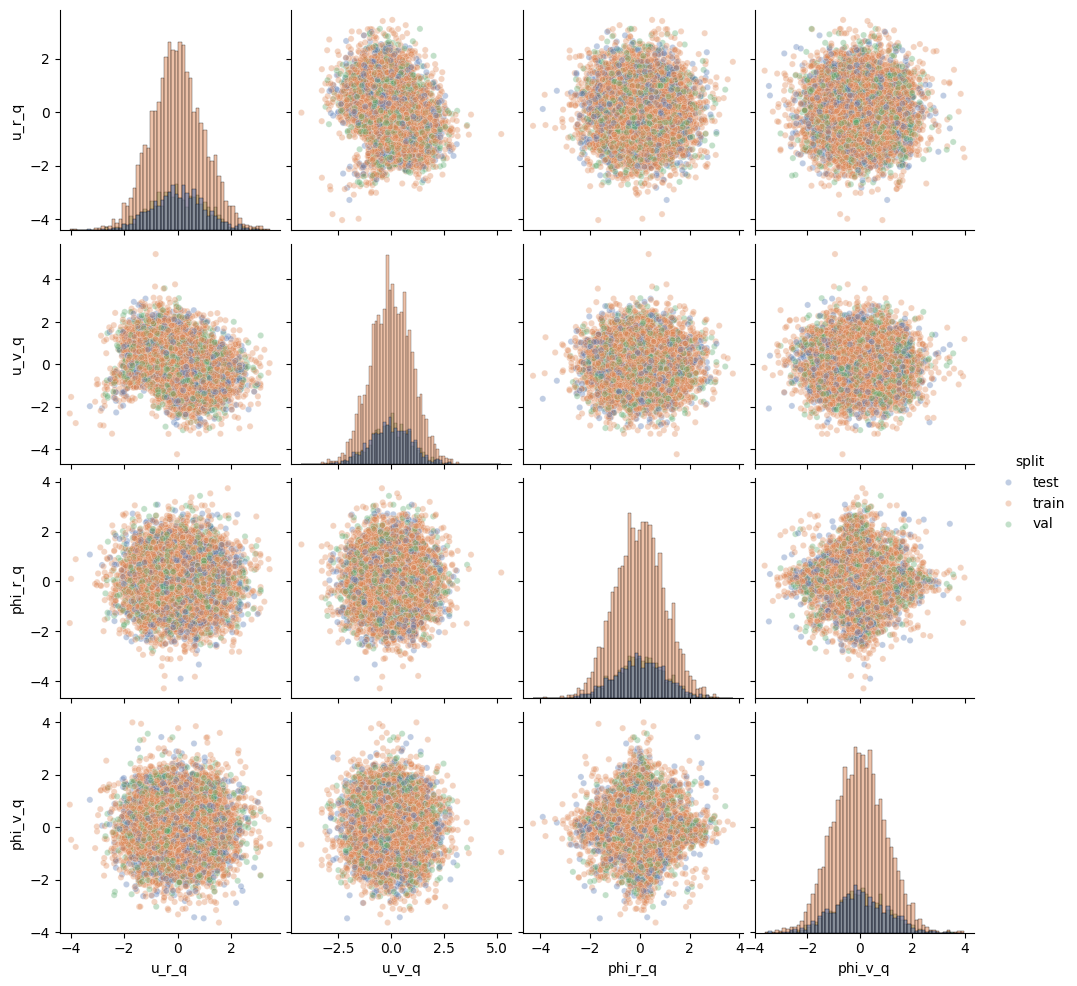

In [16]:
df_train_plot = dataset_pack["feat"].iloc[split_pack["idx_train"]].copy()
df_val_plot   = dataset_pack["feat"].iloc[split_pack["idx_val"]].copy()
df_test_plot  = dataset_pack["feat"].iloc[split_pack["idx_test"]].copy()

df_train_plot["split"] = "train"
df_val_plot["split"]   = "val"
df_test_plot["split"]  = "test"

df_all_splits = pd.concat(
    [df_train_plot, df_val_plot, df_test_plot],
    axis=0,
    ignore_index=True,
)

ge.plot_pairwise_sample(
    df_all_splits,
    cols=[
        "u_r_q",
        "u_v_q",
        "phi_r_q",
        "phi_v_q",
    ],
    class_col="split",
    sample_size=8000,
)

plt.show()

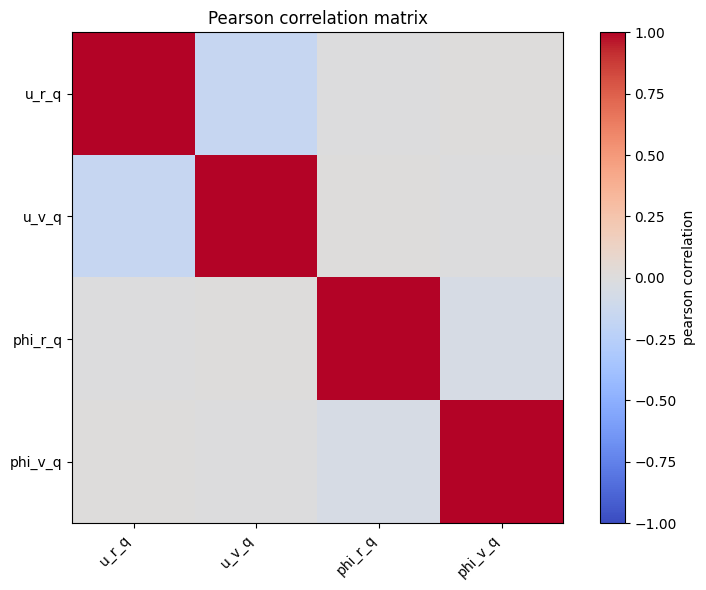

In [11]:
corr_cols = [
    "u_r_q",
    "u_v_q",
    "phi_r_q",
    "phi_v_q",
]

ge.plot_correlation_matrix(
    df_all_splits,
    corr_cols,
    method="pearson",
)

plt.show()

## Training with GEEANNT Package

### Model v 0.7.2 CVAE_CatEnergy_ContPhi_TaskAdaptive

In [17]:
# ==========================================================
# Configuration for later saving and reference - v0.7.2
# ==========================================================

model_config = {
    "model_class": "CVAE_CatEnergy_ContPhi_TaskAdaptive",
    "n_types": n_types,
    "n_energy_bins": n_energy_bins,
    "y_cont_dim": Y_CONT_DIM,

    "latent_dim": 8,
    "hidden": [128, 128, 64, 64, 64],
    "beta": 0.1,

    "w_energy": 0.8,
    "w_ur": 1.1,
    "w_uv": 1.1,
    "w_phi_r": 1.2,
    "w_phi_v": 1.2,

    "min_log_sigma": -6.0,
    "max_log_sigma": 1.5,
    "lambda_sigma": 2e-3,
    "sigma_target": -2.5,

    "energy_sampling_temperature": 1.0,

    "stem_width": 64,
    "deep_decoder_hidden": [128, 128, 64],
    "energy_branch_hidden": [48, 48],
}

preprocessing_metadata = {
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "cont_cols": cont_cols,
    "y_cont_dim": Y_CONT_DIM,

    "energy_bins": energy_bins,
    "type_probs": type_probs,
    "idx_to_type": idx_to_type,
    "n_types": n_types,

    "energy_binning_mode": feature_pack["energy_config"]["mode"],
    "energy_config": feature_pack["energy_config"],

    "geometry_metadata": geometry_metadata,
    "quantile_transformer_keys": list(quantile_transformers.keys()),
}

In [18]:
# Optional but recommended
ge.initialize_environment(seed=42, cpu_only=True, quiet=True)

n_types = int(cond_train.shape[1])

model = ge.CVAE_CatEnergy_ContPhi_TaskAdaptive(
    n_types=n_types,
    n_energy_bins=n_energy_bins,
    y_cont_dim=Y_CONT_DIM,

    latent_dim=model_config["latent_dim"],
    hidden=model_config["hidden"],
    beta=model_config["beta"],
    type_weights=type_weights,

    min_log_sigma=model_config["min_log_sigma"],
    max_log_sigma=model_config["max_log_sigma"],

    lambda_sigma=model_config["lambda_sigma"],
    sigma_target=model_config["sigma_target"],

    w_energy=model_config["w_energy"],
    w_ur=model_config["w_ur"],
    w_uv=model_config["w_uv"],
    w_phi_r=model_config["w_phi_r"],
    w_phi_v=model_config["w_phi_v"],

    energy_sampling_temperature=model_config["energy_sampling_temperature"],

    stem_width=model_config["stem_width"],
    deep_decoder_hidden=model_config["deep_decoder_hidden"],
    energy_branch_hidden=model_config["energy_branch_hidden"],
)

ge.compile_model(
    model,
    learning_rate=2e-4,
)

energy_dist_cb = ge.ValidationEnergyDistributionMonitor(
    E_val_raw=E_val_raw,
    energy_bins=energy_bins,
    type_probs=type_probs,
    n_types=n_types,
    n_samples=n_energy_bins * 1000,
    energy_mode="uniform",
    min_real_count=250,
    seed=42,
    every_n_epochs=1,
    verbose=1,
)

adaptive_cb = ge.TaskAdaptiveLossScheduler(
    task_configs={
        "energy": {
            "monitor": "val_energy_quality_score",
            "threshold": 1,
            "patience": 5,
            "min_delta": 0.005,
            "decay_factor": 0.8,
            "min_weight": 0.05,
            "cooldown": 1,
        }
    },
    verbose=1,
)

monitor_cb = ge.TaskAdaptiveTrainingMonitor(
    scheduler=adaptive_cb,
    metrics_to_show=[
        "loss",
        "val_loss",
        "rec",
        "val_rec",
        "kl",
        "val_kl",
        "nll",
        "val_nll",

        "energy_ce",
        "val_energy_ce",

        "ur_nll",
        "val_ur_nll",
        "uv_nll",
        "val_uv_nll",
        "phi_r_nll",
        "val_phi_r_nll",
        "phi_v_nll",
        "val_phi_v_nll",

        "sigma_reg",
        "val_sigma_reg",

        "val_energy_mean_rel_err",
        "val_energy_max_rel_err",
        "val_energy_p90_rel_err",
        "val_energy_quality_score",
        "val_energy_wdist",
    ],
    show_task_weights=True,
    show_scheduler_state=True,
    every_n_epochs=1,
)

callbacks = ge.build_default_callbacks(
    monitor="val_loss",
    early_patience=8,
    lr_patience=6,
    factor=0.5,
    min_lr=1e-5,
    verbose=1,
)

callbacks.append(energy_dist_cb)
callbacks.append(adaptive_cb)
callbacks.append(monitor_cb)

# DUMMY BUILD FOR STRUCTURE INSPECTION
dummy_z = tf.zeros((1, model.latent_dim), dtype=tf.float32)
dummy_cond = tf.zeros((1, n_types), dtype=tf.float32)
_ = model.decode(dummy_z, dummy_cond)

ge.print_model_tree_with_params(model)
# ge.print_model_structure(model)
ge.print_duplicate_trainable_variables(model)


===== GEEANNT MODEL TREE (WITH PARAMS) =====
CVAE_CatEnergy_ContPhi_TaskAdaptive
│
├── Encoder [trainable] (total=68304, trainable=68304, non_trainable=0)
│   ├── input: [y_cont, E_onehot, cond]
│   ├── z_mean
│   └── z_logvar
│
├── Decoder stem [trainable] (total=960, trainable=960, non_trainable=0)
│   └── light shared representation
│
├── Energy branch (short path) [trainable] (total=5472, trainable=5472, non_trainable=0)
│   └── energy_logits_head [trainable] (total=12544, trainable=12544, non_trainable=0)
│
├── Decoder deep trunk [trainable] (total=33088, trainable=33088, non_trainable=0)
│   └── deep shared representation
│   ├── Position branch [trainable] (total=33088, trainable=33088, non_trainable=0)
│   │   ├── ur_head [trainable] (total=16576, trainable=16576, non_trainable=0)
│   │   │   ├── ur_mu_head [trainable] (total=65, trainable=65, non_trainable=0)
│   │   │   └── ur_logsigma_head [trainable] (total=65, trainable=65, non_trainable=0)
│   │   ├── phi_r_head [trainab

In [27]:
ge.print_model_structure(model)


===== GEEANNT MODEL STRUCTURE =====
Model class   = CVAE_CatEnergy_ContPhi_TaskAdaptive
latent_dim    = 8
n_types       = 6
n_energy_bins = 256
y_cont_dim    = 4

--- Encoder ---


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 266)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     34,176 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 64)        │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 64)        │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 64)        │          0 │ dense_4[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        520 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logvar (Dense)    │ (None, 8)         │        520 │ leaky_re_lu_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,304 (266.81 KB)

 Trainable params: 68,304 (266.81 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,576 (64.75 KB)

 Trainable params: 16,576 (64.75 KB)

 Non-trainable params: 0 (0.00 B)


--- ur_mu_head ---
<Dense name=ur_mu, built=True>

--- ur_logsigma_head ---
<Dense name=ur_logsigma, built=True>

--- uv_mu_head ---
<Dense name=uv_mu, built=True>

--- uv_logsigma_head ---
<Dense name=uv_logsigma, built=True>

--- phi_r_mu_head ---
<Dense name=phi_r_mu, built=True>

--- phi_r_logsigma_head ---
<Dense name=phi_r_logsigma, built=True>

--- phi_v_mu_head ---
<Dense name=phi_v_mu, built=True>

--- phi_v_logsigma_head ---
<Dense name=phi_v_logsigma, built=True>

--- energy_logits_head ---
<Dense name=energy_logits, built=True>

--- Task / loss weights ---
  energy : 0.8
      ur : 1.1
      uv : 1.1
   phi_r : 1.2
   phi_v : 1.2


In [19]:
history = ge.fit_model(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=40,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/40
589/589 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - energy_ce: 5.1563 - kl: 1.6059 - loss: 1.3642 - nll: 5.1058 - phi_r_nll: 0.4993 - phi_v_nll: 0.5103 - rec: 1.1619 - sigma_reg: 0.0417 - ur_nll: 0.0734 - uv_nll: -0.2833
[ValidationEnergyDistributionMonitor] Epoch 1: mean_rel_err=0.098022, max_rel_err=0.621245, p90_rel_err=0.217725, quality_score=2.484979, valid_bins=154, val_energy_wdist=0.033494

[TrainingMonitor] Epoch 1
  lr = 2.000000e-04
  Metrics:
                loss : 1.078338
            val_loss : 0.659486
                 rec : 0.688195
             val_rec : 0.023628
                  kl : 3.566109
              val_kl : 6.107205
                 nll : 3.096534
             val_nll : 0.274136
           energy_ce : 4.769573
       val_energy_ce : 4.229250
              ur_nll : -0.584787
          val_ur_nll : -1.695230
              uv_nll : -1.171558
          val_uv_nll : -2.233478
           phi_r_nll : 0.500081
       val_phi_r_nll : 0.499885
           phi_v_nll :


Available history keys:
['energy_ce', 'kl', 'loss', 'nll', 'phi_r_nll', 'phi_v_nll', 'rec', 'sigma_reg', 'ur_nll', 'uv_nll', 'val_energy_ce', 'val_kl', 'val_loss', 'val_nll', 'val_phi_r_nll', 'val_phi_v_nll', 'val_rec', 'val_sigma_reg', 'val_ur_nll', 'val_uv_nll', 'learning_rate', 'val_energy_mean_rel_err', 'val_energy_max_rel_err', 'val_energy_p90_rel_err', 'val_energy_quality_score', 'val_energy_n_valid_bins', 'val_energy_valid_bin_fraction', 'val_energy_hist_err', 'val_energy_wdist']


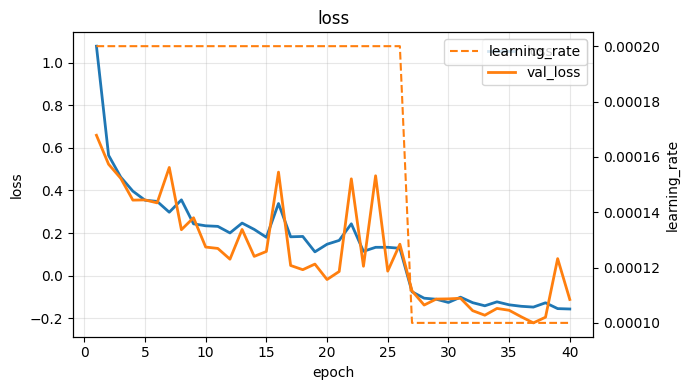

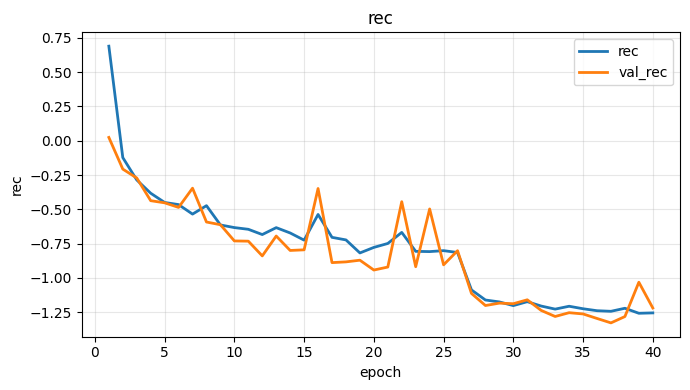

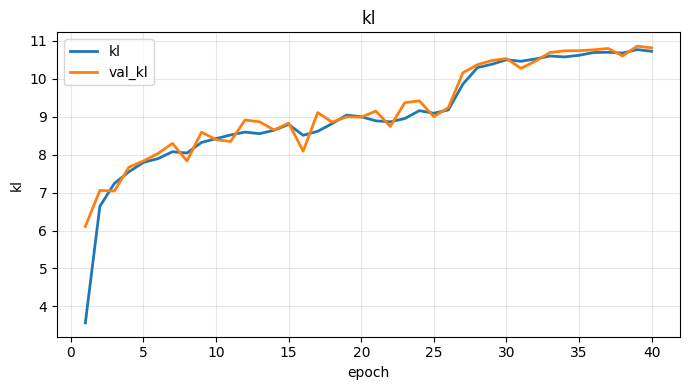

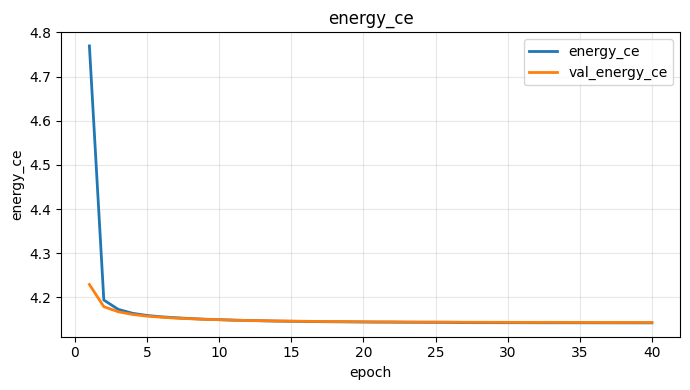

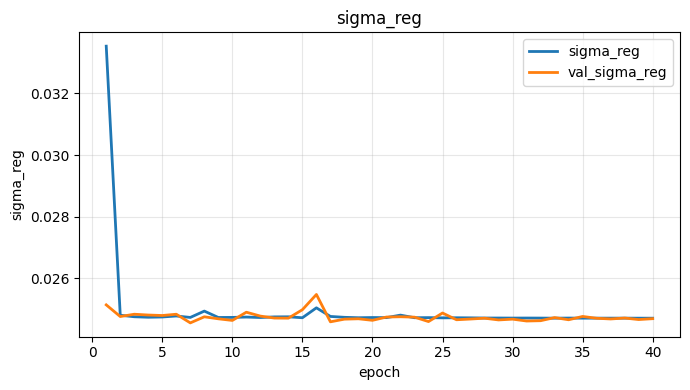

In [20]:
ge.plot_history(history)

## Generation and Validation

In [ ]:
### SKIP MODEL TRAINING AND DIRECTLY LOAD A TRAINED MODEL FOR GENERATION AND EVALUATION

model_config = {
    "model_class": "CVAE_CatEnergy_ContPhi_TaskAdaptive",

    "n_types": n_types,
    "n_energy_bins": n_energy_bins,
    "y_cont_dim": Y_CONT_DIM,

    "latent_dim": 8,
    "hidden": [128, 128, 64, 64, 64],
    "beta": 0.1,

    "w_energy": 0.8,
    "w_ur": 1.1,
    "w_uv": 1.1,
    "w_phi_r": 1.2,
    "w_phi_v": 1.2,

    "min_log_sigma": -6.0,
    "max_log_sigma": 1.5,

    "lambda_sigma": 2e-3,
    "sigma_target": -2.5,

    "energy_sampling_temperature": 1.0,

    "stem_width": 64,
    "deep_decoder_hidden": [128, 128, 64],
    "energy_branch_hidden": [48, 48],
}

preprocessing_metadata = {
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "cont_cols": cont_cols,
    "y_cont_dim": Y_CONT_DIM,

    "energy_bins": energy_bins,
    "type_probs": type_probs,
    "idx_to_type": idx_to_type,
    "n_types": n_types,

    "energy_binning_mode": feature_pack["energy_config"]["mode"],
    "energy_config": feature_pack["energy_config"],
    "geometry_metadata": geometry_metadata,
    "quantile_transformer_keys": list(quantile_transformers.keys()),
}

model = ge.load_task_adaptive_model_for_generation(
    save_dir="trained_models/task_adaptive_energy_contphi_run_001",
    model_name="task_adaptive_cvae_energy_contphi",
    model_config=model_config,
    energy_bins=energy_bins,
    u_v_bins=None,          # v0.7.2: not used
    n_types=n_types,
    type_weights=type_weights,
    radius=R,
    compile_model_fn=None,
    verbose=1,
)

Loaded task-adaptive model.
Model class: CVAE_CatEnergy_ContGeom_TaskAdaptive
Weights: trained_models/task_adaptive_energy_cont_run_001/task_adaptive_cvae_energy_cont.weights.h5
Task weights: trained_models/task_adaptive_energy_cont_run_001/task_adaptive_cvae_energy_cont_task_weights.json
Current task weights: {'energy': 0.2621440000000001, 'ur': 1.1, 'uv': 1.1, 'phi_r': 1.4, 'phi_v': 1.1}


In [21]:
NGEN = len(X_cont_test)
# NGEN = int(1e6)

gen_raw = ge.generate_latent_outputs(
    model=model,
    n_samples=NGEN,
    type_probs=type_probs,
    n_types=n_types,
    idx_to_type=idx_to_type,
)

gen_feat = ge.reconstruct_generated_features(
    gen_raw,
    energy_bins=energy_bins,
    energy_mode="uniform",
    qt_u_r=qt_u_r,
    qt_u_v=qt_u_v,
    qt_phi_r=qt_phi_r,
    qt_phi_v=qt_phi_v,
    geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
)

gen_phys = ge.reconstruct_generated_physics(
    gen_feat,
    center=center,
    radius=R,
)

real_phys = ge.reconstruct_real_test_physics(
    X_cont_test=X_cont_test,
    E_test_raw=E_test_raw,
    qt_u_r=qt_u_r,
    qt_u_v=qt_u_v,
    qt_phi_r=qt_phi_r,
    qt_phi_v=qt_phi_v,
    center=center,
    radius=R,
    geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
)

real_phys["phi_r_real"] = np.arctan2(
    real_phys["sphi_r_real"],
    real_phys["cphi_r_real"],
)

real_phys["phi_v_real"] = np.arctan2(
    real_phys["sphi_v_real"],
    real_phys["cphi_v_real"],
)

gen_phys["phi_r_gen"] = np.arctan2(
    gen_phys["sphi_r_gen"],
    gen_phys["cphi_r_gen"],
)

gen_phys["phi_v_gen"] = np.arctan2(
    gen_phys["sphi_v_gen"],
    gen_phys["cphi_v_gen"],
)

ge.report_generated_constraints(gen_phys, radius=R)

scores = ge.compute_wasserstein_scores(real_phys, gen_phys)
print(scores)

--- CONSTRAINT CHECKS ---

Sphere constraint:
r_gen: mean 99.99999999993042 std 2.7894543531140506e-11 min 99.99999999989997 max 100.00000000000003
mean |r-R| = 6.958409714629651e-11

Direction norm:
||v||: mean 0.9999999999989986 std 1.3905593402784028e-15 min 0.9999999999989997 max 0.9999999999990002
mean ||v||-1| = 1.000033097466802e-12

Unit circle checks:
phi_r norm: mean 0.9999999999989986 std 1.3558142515965218e-15 min 0.9999999999989998 max 0.9999999999990002
phi_v norm: mean 0.9999999999989986 std 1.3556050399168632e-15 min 0.9999999999989997 max 0.9999999999990002

Physical variables:
E_gen: min 0.00039796173 max 508864.72
u_r_gen min/max: -0.9976565559679766 0.999974742488256
u_v_gen min/max: -0.9999415241359181 0.03646981363572012
fraction u_v_gen > 0: 0.0072998917889284

Quantile variables:
u_r_q_gen: min=-4.089970588684082 max=4.410691738128662 mean=-0.012248406186699867 std=0.8500848412513733
u_v_q_gen: min=-4.252386569976807 max=4.511657238006592 mean=-0.001125022303313

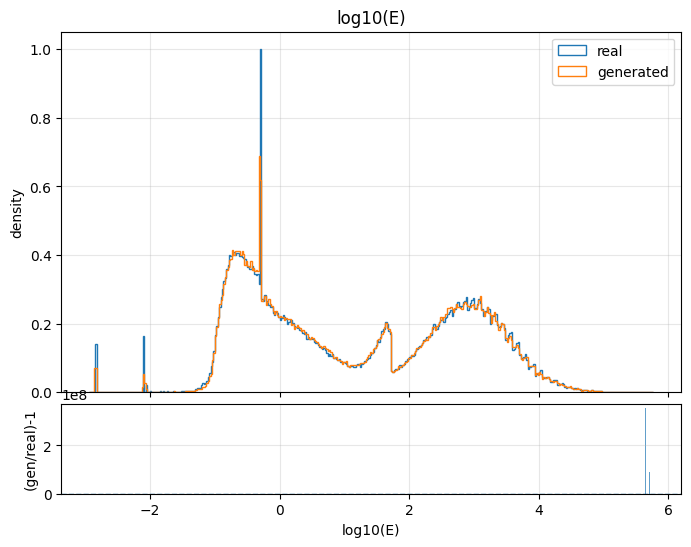

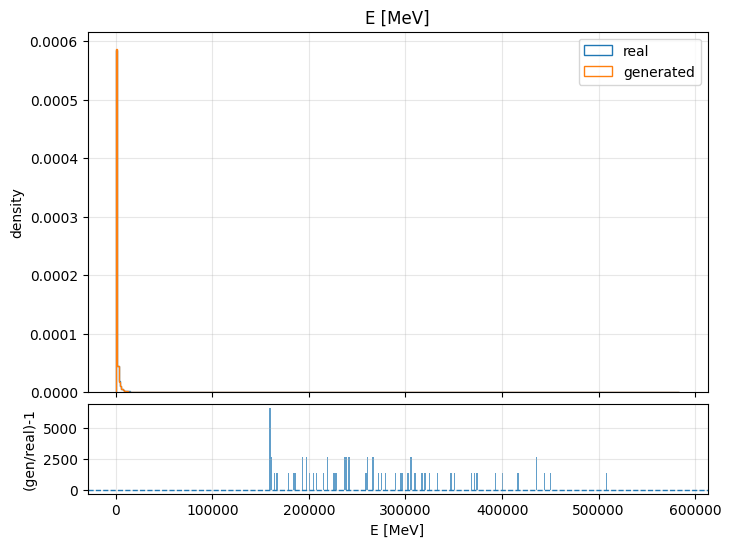

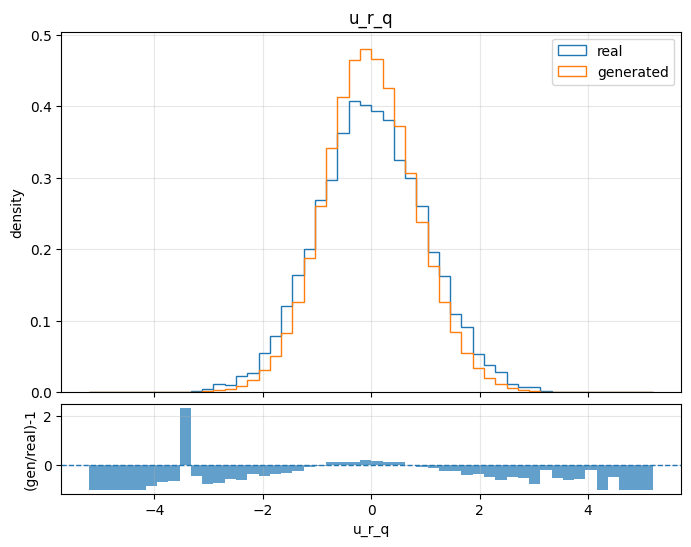

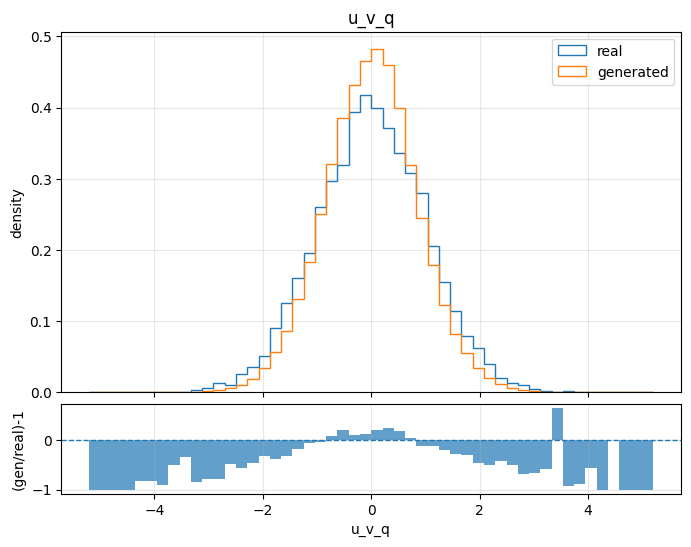

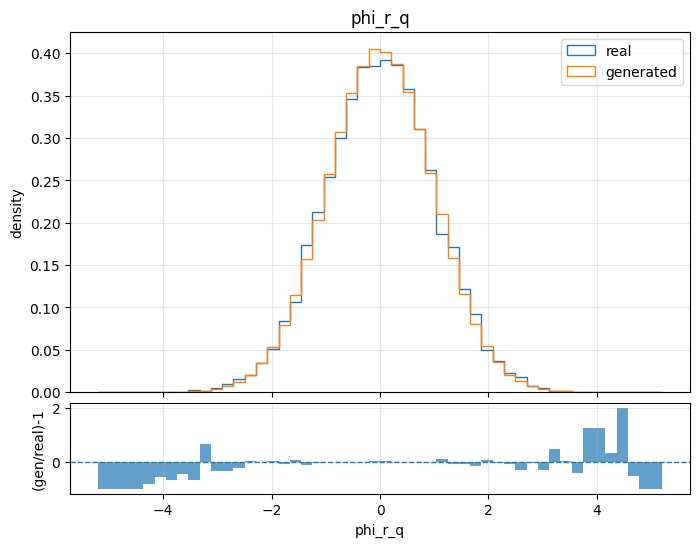

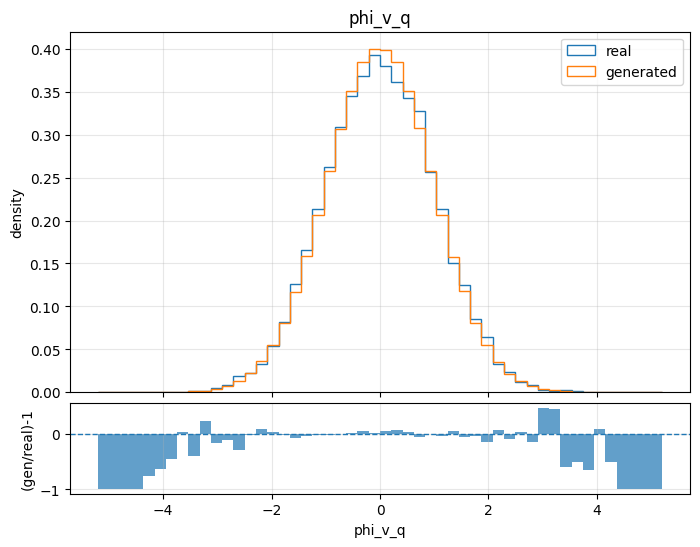

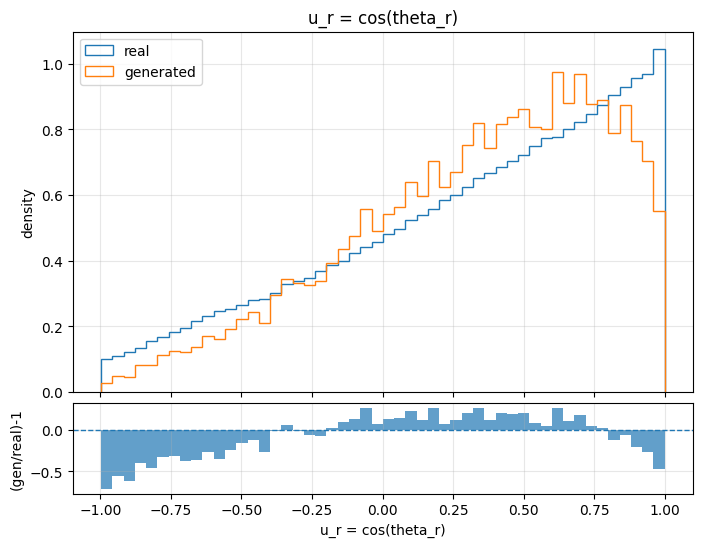

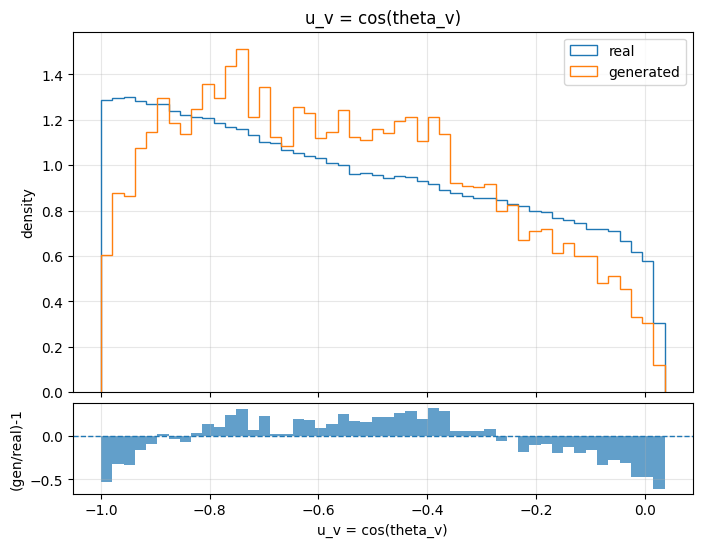

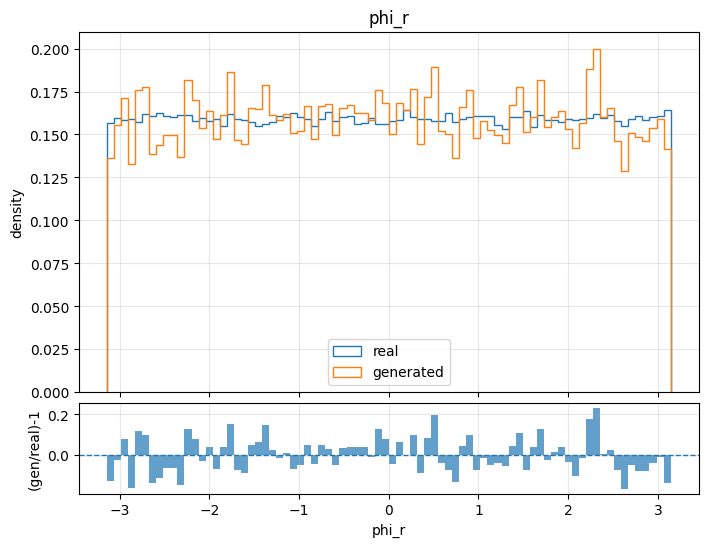

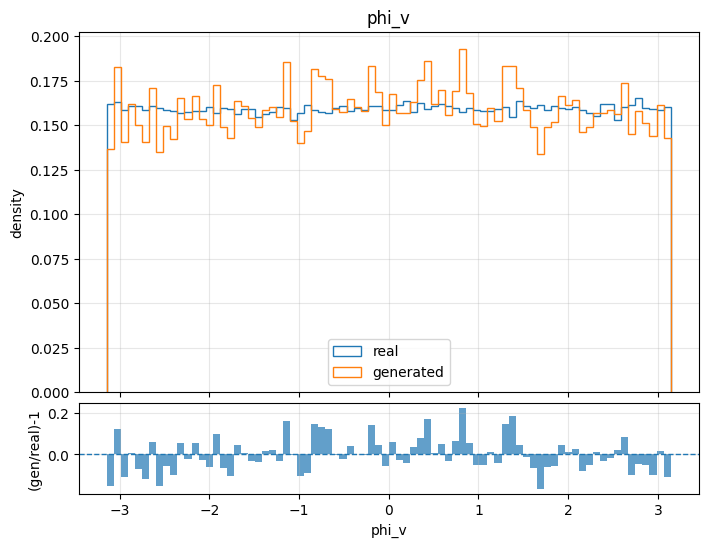

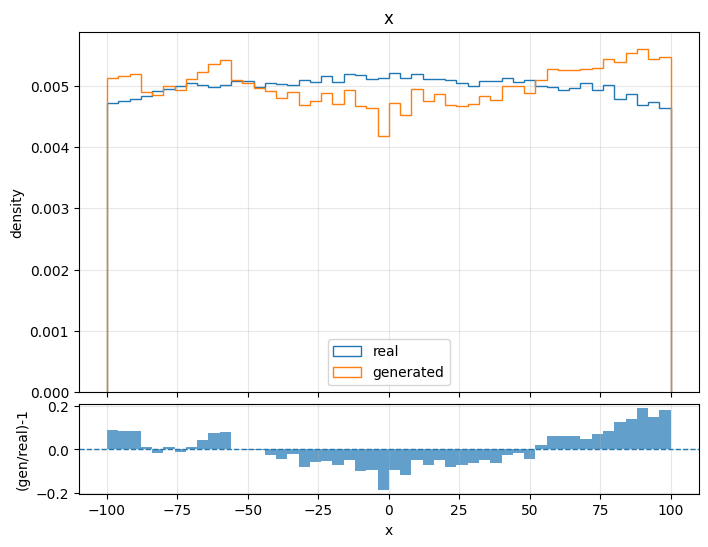

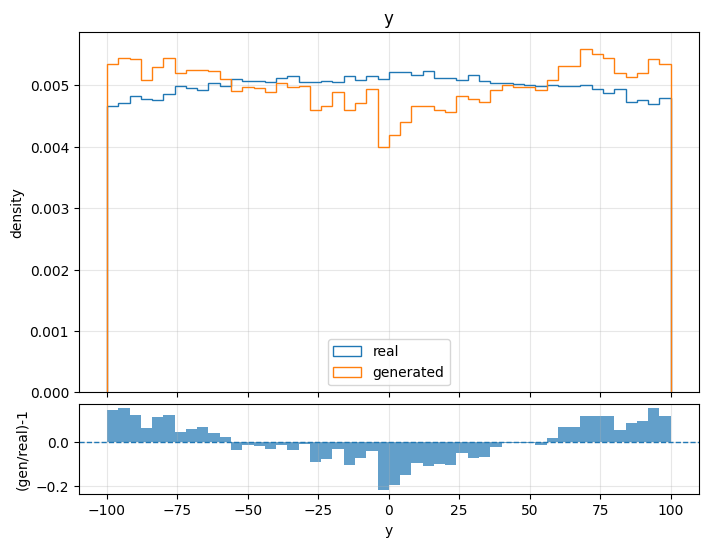

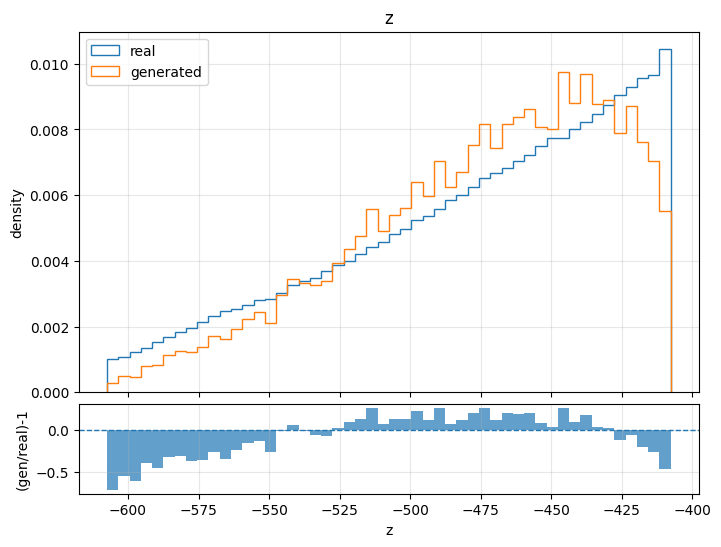

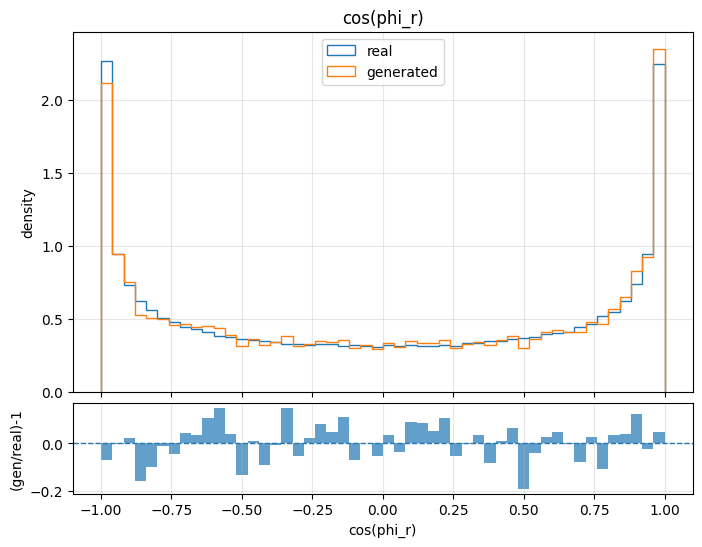

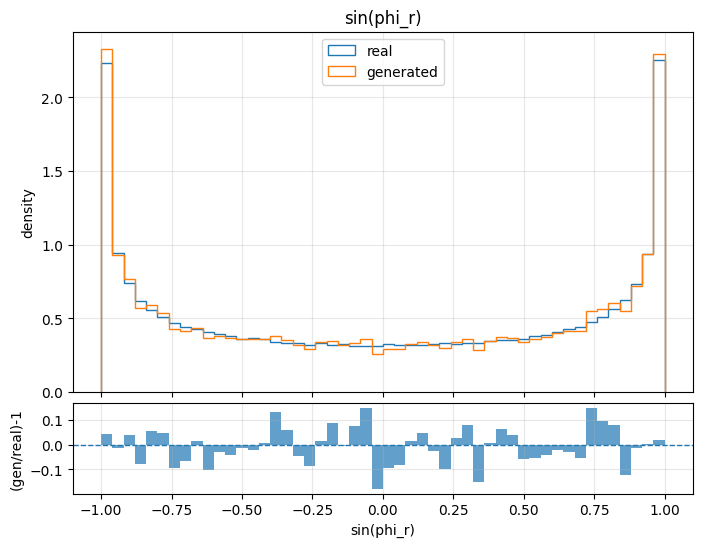

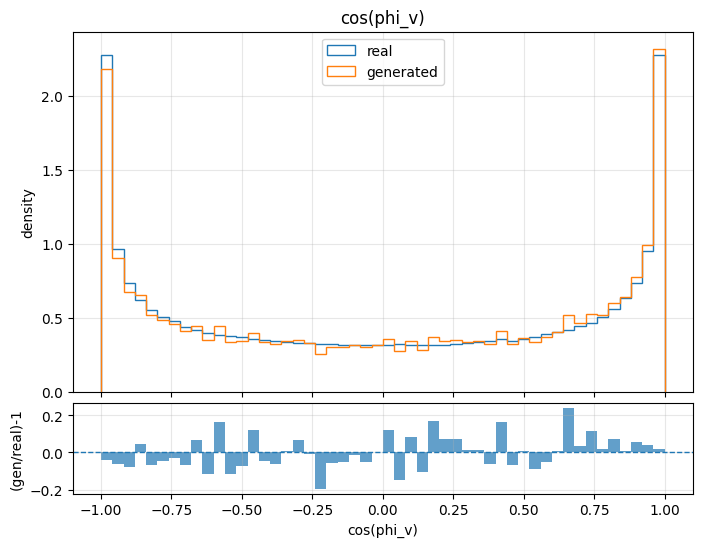

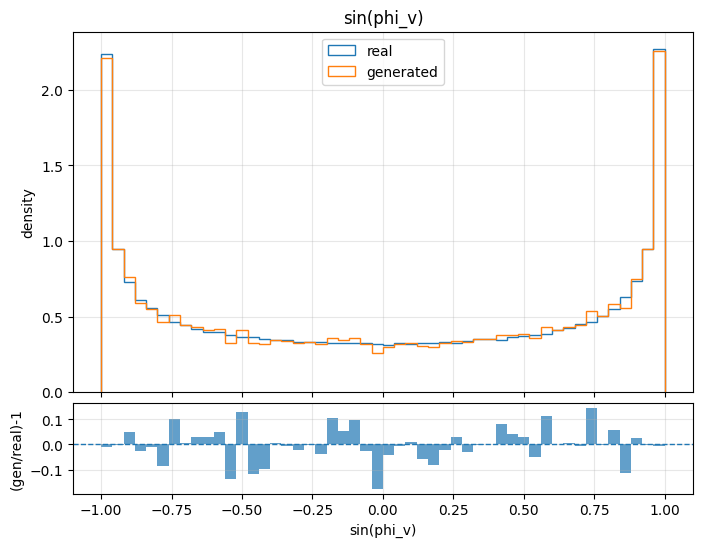

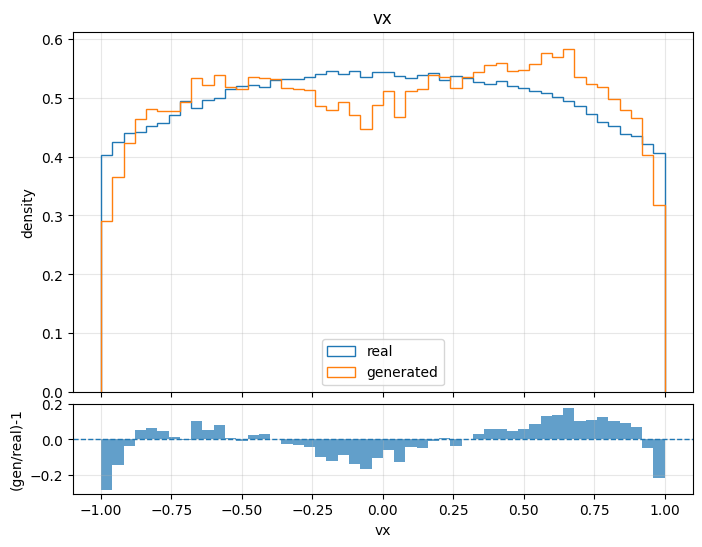

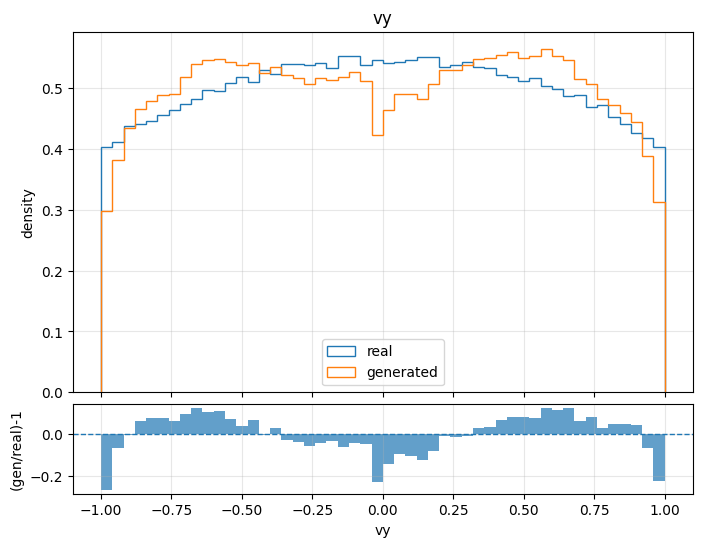

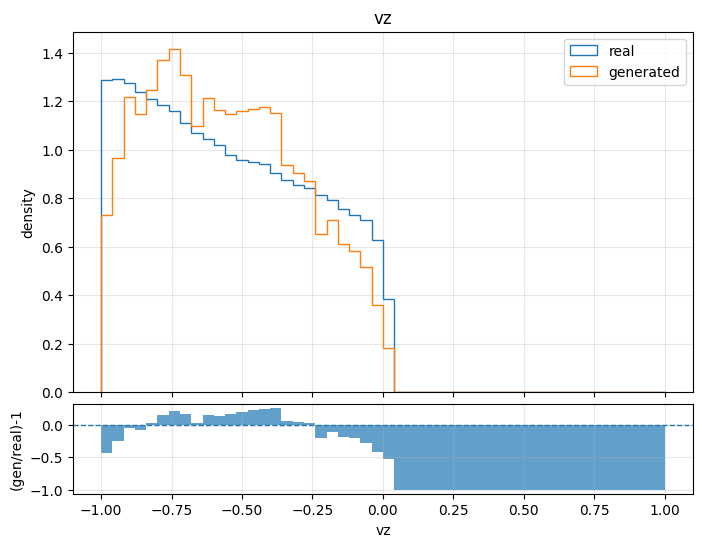


--- RANGE CHECK ---
logE real/gen: -2.9367342115653177 5.766049047518101 | -3.4001586 5.7066026
u_v  real/gen: -0.9999502576772353 0.03650256144934196 | -0.9999415241359181 0.03646981363572012

Position:
x real/gen: -99.99894983958973 99.99864141892914 | -99.99620455099296 99.99987131981125
y real/gen: -99.99965566305174 99.99987687991835 | -99.99993714090772 99.9995677847969
z real/gen: -607.4655070358577 -407.6622257404615 | -607.4256555967977 -407.6625257511744

Direction:
cphi_v real/gen: -0.999999838903321 0.9999999998375155 | -0.9999998395483729 0.9999999999415607
sphi_v real/gen: -0.9999999999987308 0.999999999996139 | -0.9999999999962519 0.999999999972932
vx real/gen: -0.9999972553146266 0.9999983715882191 | -0.9999966717153143 0.9999939357000068
vy real/gen: -0.9999962041409057 0.9999990135175159 | -0.9999963103495098 0.9999827473005201
vz real/gen: -0.9999502576772353 0.03650256144934196 | -0.9999415241349183 0.03646981363572007

--- COS/SIN NORM CHECK ---
phi_r real/gen: 0.

In [22]:
ge.set_plot_theme("light")

# ==========================================================
# Energy
# ==========================================================

ge.compare_hist_with_residuals(
    real_phys["logE_real"],
    gen_phys["logE_gen"],
    "log10(E)",
    bins=400,
)

ge.compare_hist_with_residuals(
    real_phys["E_real"],
    gen_phys["E_gen"],
    "E [MeV]",
    bins=400,
    savepath="./Plots/energy_distribution_cr_v072.png",
    dpi=300,
    show=True,
)

# ==========================================================
# Quantile-space variables, model native space
# ==========================================================

for key, label in [
    ("u_r_q", "u_r_q"),
    ("u_v_q", "u_v_q"),
    ("phi_r_q", "phi_r_q"),
    ("phi_v_q", "phi_v_q"),
]:
    ge.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Physical spherical variables
# ==========================================================

for key, label in [
    ("u_r", "u_r = cos(theta_r)"),
    ("u_v", "u_v = cos(theta_v)"),
]:
    plot_range = (
        min(real_phys[f"{key}_real"].min(), gen_phys[f"{key}_gen"].min()),
        max(real_phys[f"{key}_real"].max(), gen_phys[f"{key}_gen"].max()),
    )

    ge.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        range_=plot_range,
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Physical angular variables
# ==========================================================

for key, label in [
    ("phi_r", "phi_r"),
    ("phi_v", "phi_v"),
]:
    ge.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        range_=(-np.pi, np.pi),
        ratio_clip=5,
        bins=80,
    )

# ==========================================================
# Cartesian position
# ==========================================================

for key in ["x", "y", "z"]:
    ge.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        key,
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Angular position/direction components
# ==========================================================

for key, label in [
    ("cphi_r", "cos(phi_r)"),
    ("sphi_r", "sin(phi_r)"),
    ("cphi_v", "cos(phi_v)"),
    ("sphi_v", "sin(phi_v)"),
]:
    ge.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        range_=(-1, 1),
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Cartesian direction
# ==========================================================

for key in ["vx", "vy", "vz"]:
    ge.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        key,
        range_=(-1, 1),
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Final reports
# ==========================================================

ge.report_final_ranges(real_phys, gen_phys)
ge.report_norm_checks(real_phys, gen_phys)

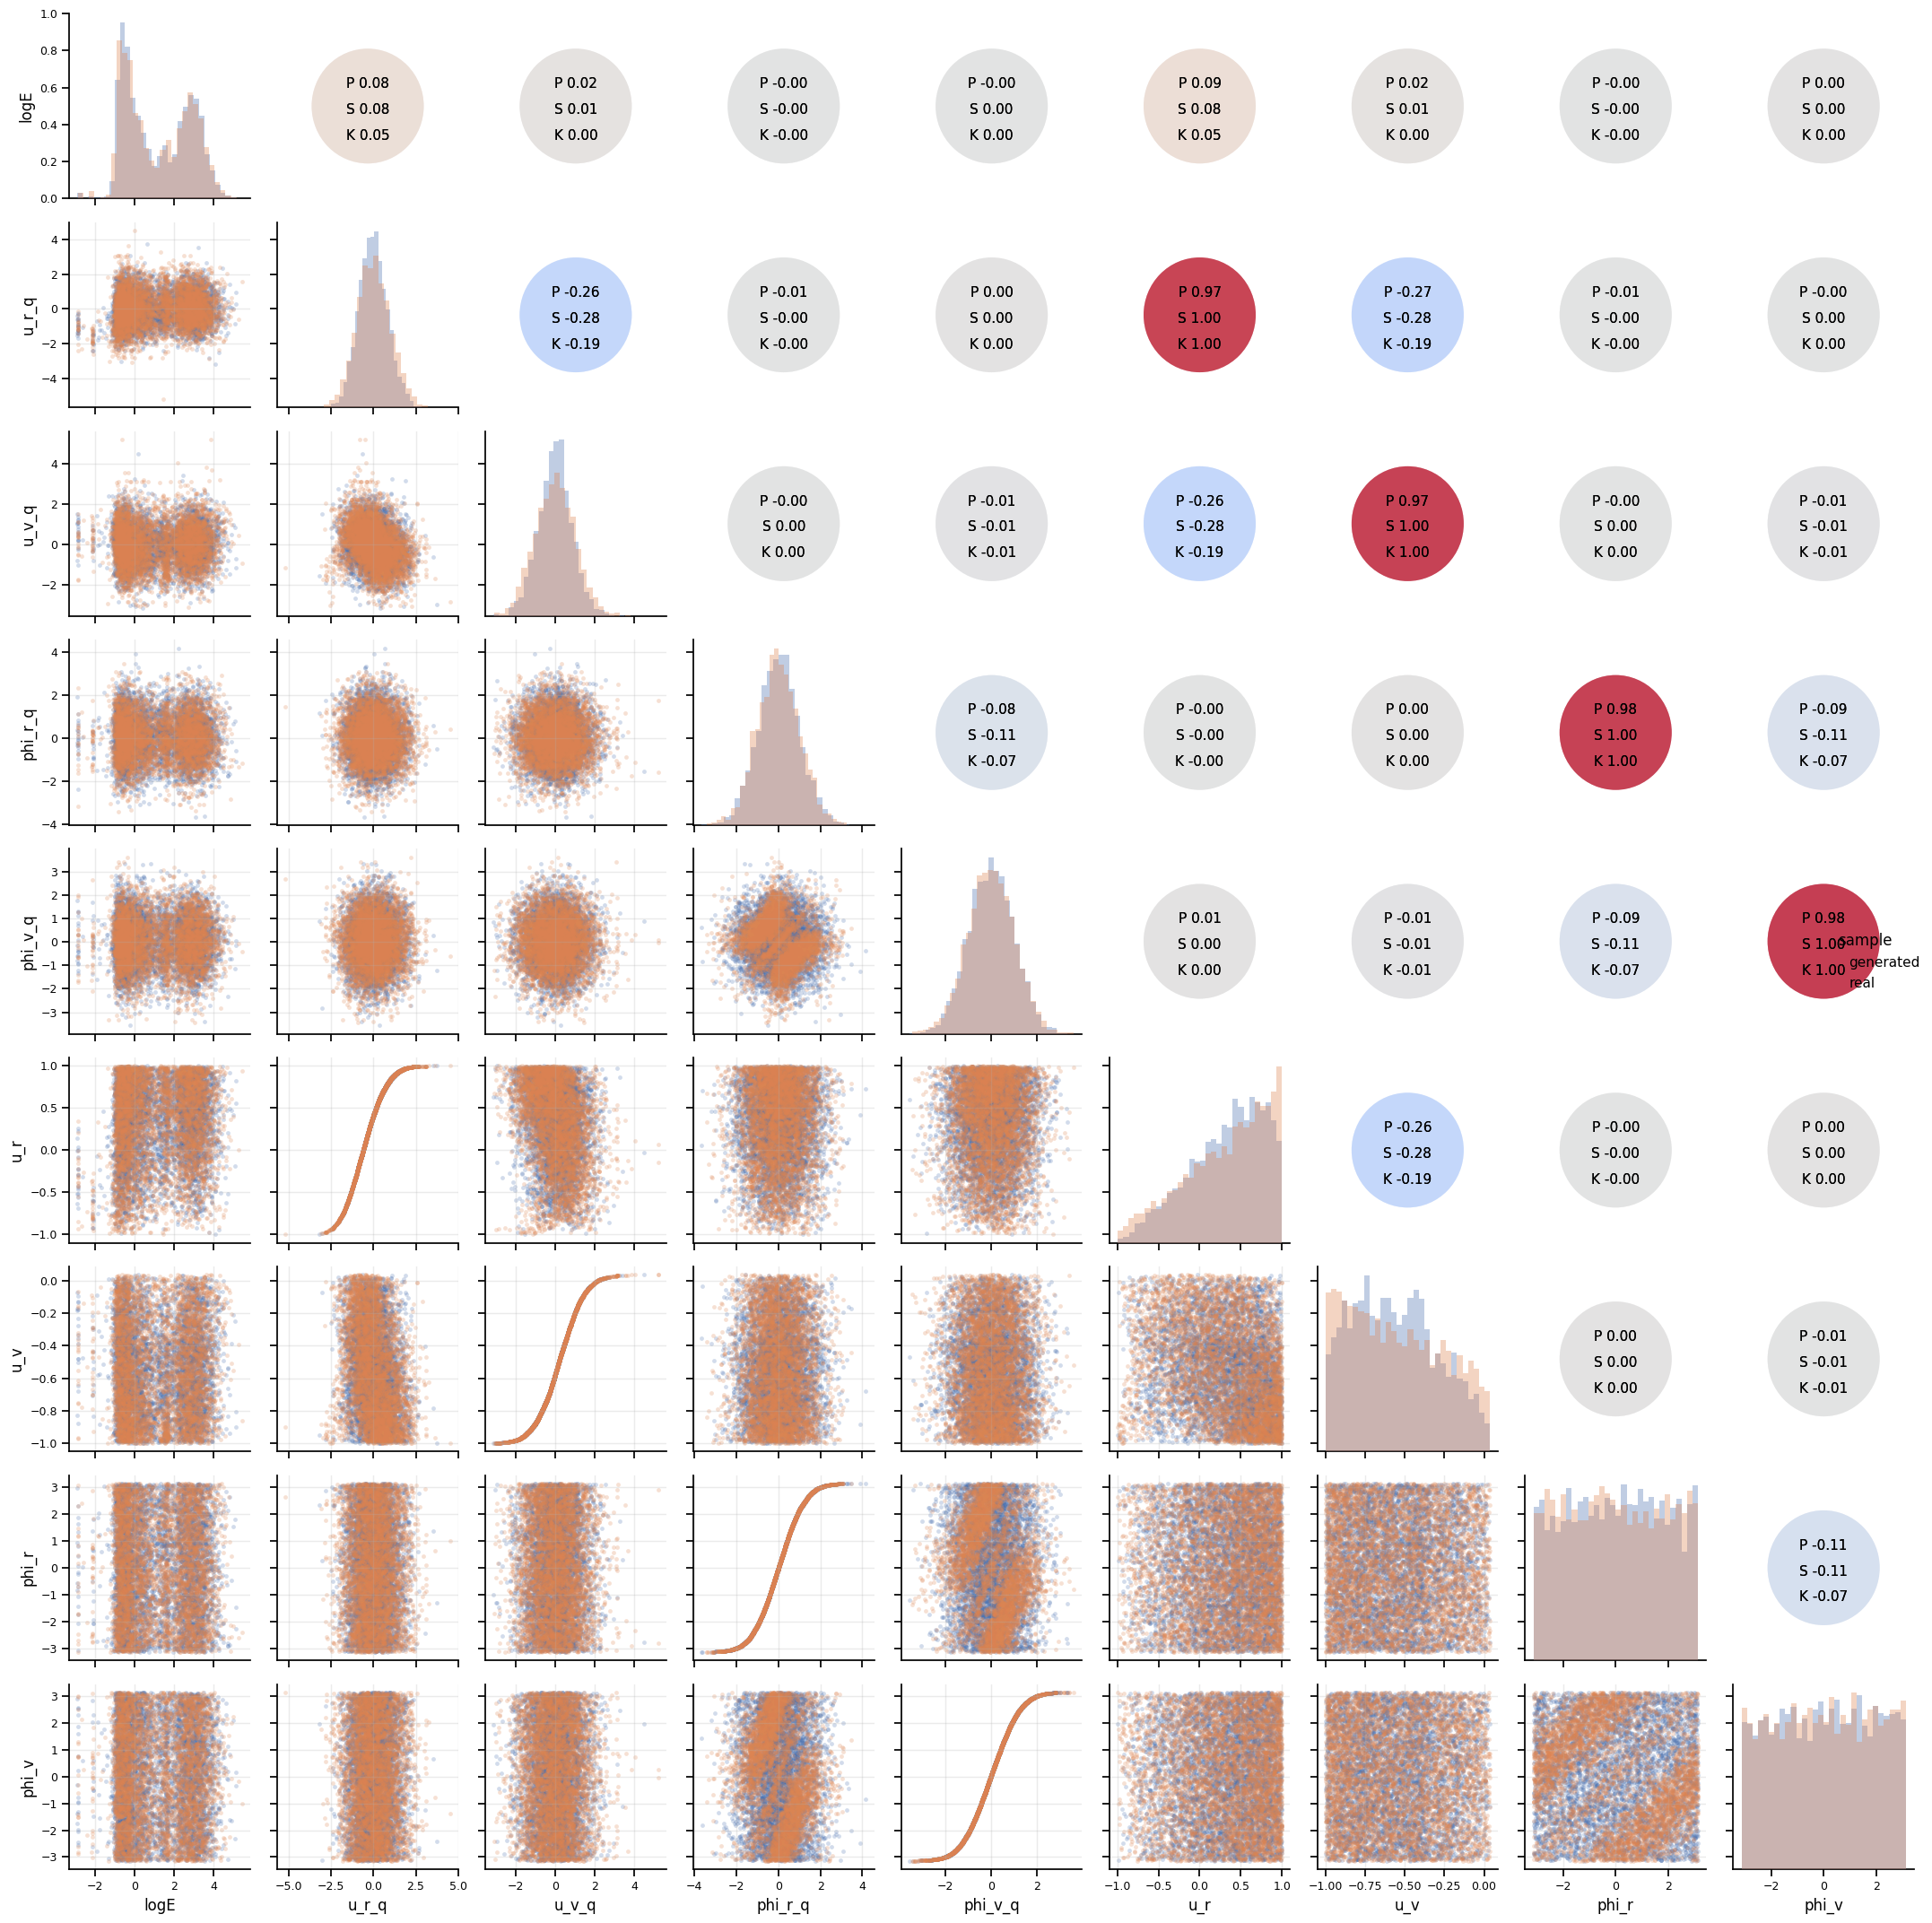

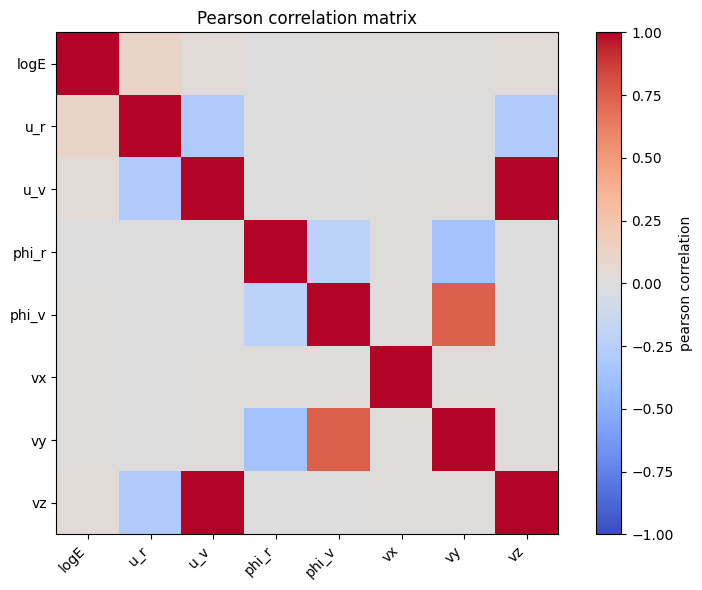

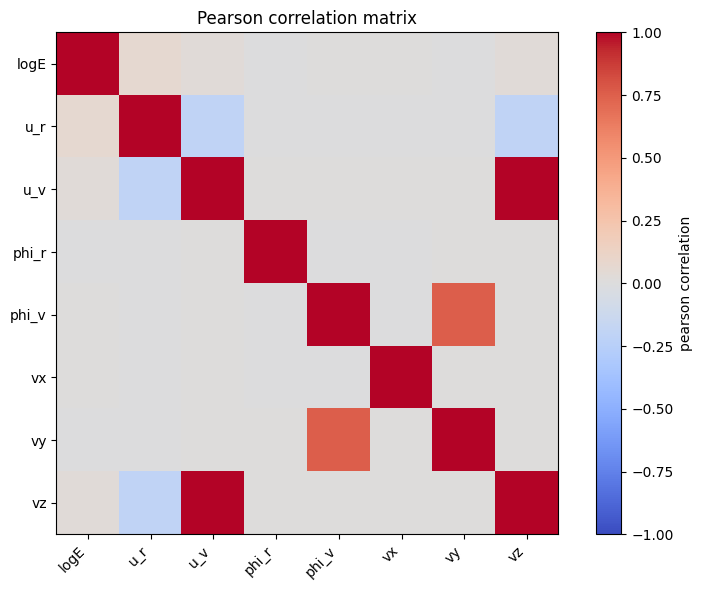

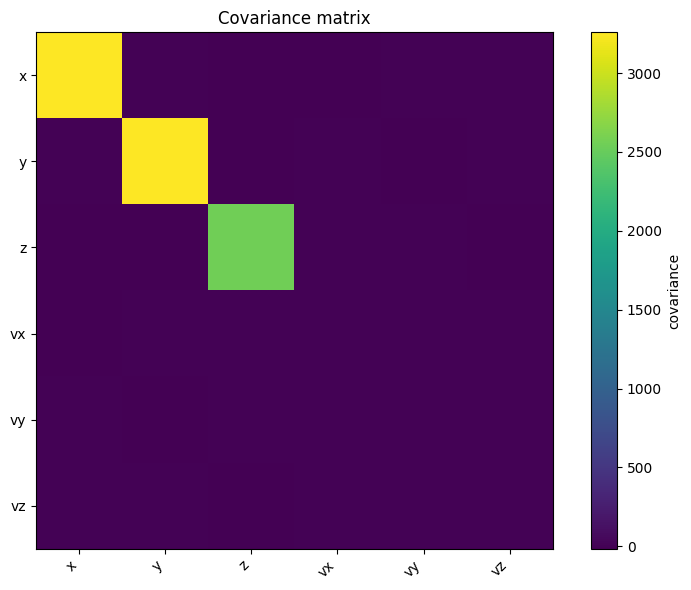

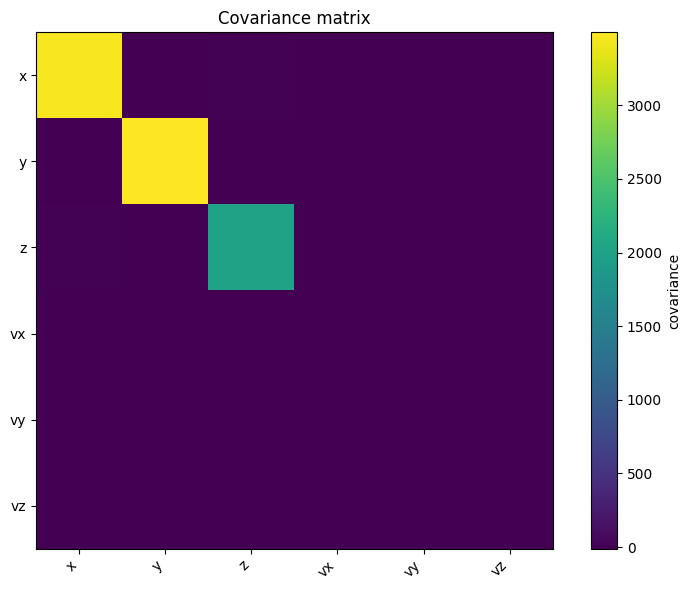

(<Figure size 800x600 with 2 Axes>,
               x            y            z        vx        vy        vz
 x   3461.661997   -11.361900     4.967353  0.059283 -0.055062  0.027228
 y    -11.361900  3495.468986    -3.326011 -0.041782  0.055327  0.041157
 z      4.967353    -3.326011  2008.120235 -0.045361 -0.025756 -2.305816
 vx     0.059283    -0.041782    -0.045361  0.313003  0.000461  0.001116
 vy    -0.055062     0.055327    -0.025756  0.000461  0.311572  0.000471
 vz     0.027228     0.041157    -2.305816  0.001116  0.000471  0.068437)

In [23]:
df_real_plot, df_gen_plot, df_compare = ge.build_real_generated_featureframes(
    real_phys,
    gen_phys,
)

# ==========================================================
# Pairgrid: model-native + physical angular variables
# ==========================================================

corr_cols_compare = [
    "logE",

    "u_r_q",
    "u_v_q",
    "phi_r_q",
    "phi_v_q",

    "u_r",
    "u_v",
    "phi_r",
    "phi_v",
]

ge.plot_pairgrid_physics(
    df_compare,
    cols=corr_cols_compare,
    class_col="sample",
    sample_size=10000,
    lower_mode="scatter",
    bins=30,
    contour_levels=8,
    figsize_scale=2.4,
)

plt.show()

# ==========================================================
# Correlation matrices
# ==========================================================

corr_cols_phys = [
    "logE",
    "u_r",
    "u_v",
    "phi_r",
    "phi_v",
    "vx",
    "vy",
    "vz",
]

ge.plot_correlation_matrix(
    df_real_plot,
    corr_cols_phys,
    method="pearson",
)

ge.plot_correlation_matrix(
    df_gen_plot,
    corr_cols_phys,
    method="pearson",
)

# ==========================================================
# Covariance matrices
# ==========================================================

ge.plot_covariance_matrix(
    df_real_plot,
    ["x", "y", "z", "vx", "vy", "vz"],
)

ge.plot_covariance_matrix(
    df_gen_plot,
    ["x", "y", "z", "vx", "vy", "vz"],
)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


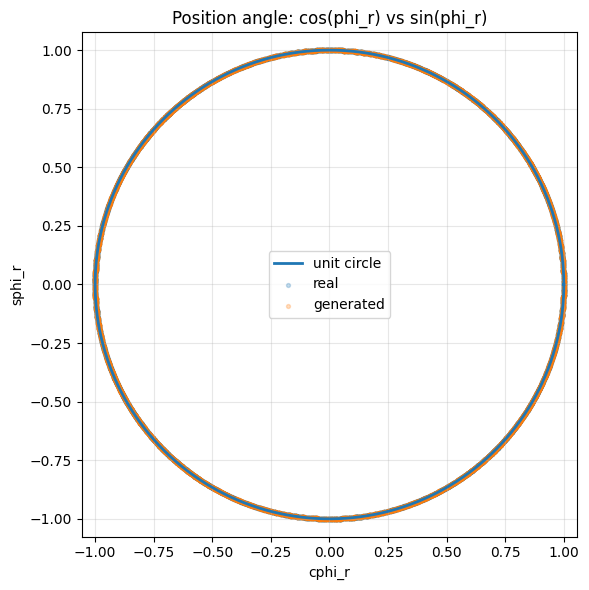

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


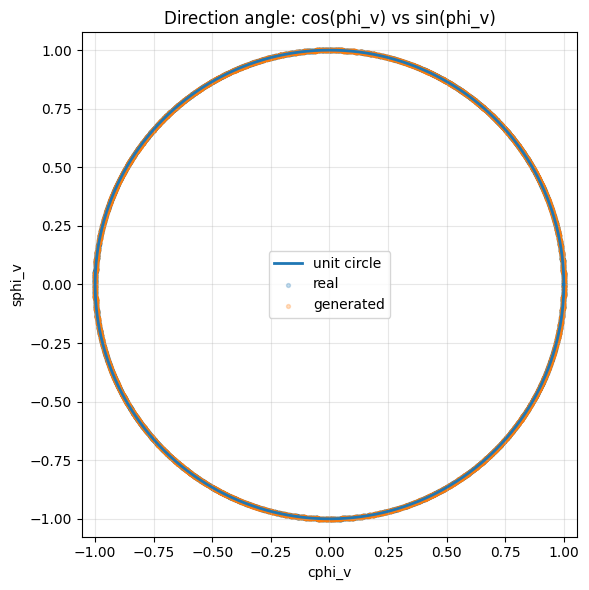

In [24]:
# ==========================================================
# Unit-circle scatter checks: cos(phi) vs sin(phi)
# ==========================================================

def plot_unit_circle_phi(df_real, df_gen, c_col, s_col, title, sample_size=10000):
    df_r = df_real[[c_col, s_col]].copy()
    df_g = df_gen[[c_col, s_col]].copy()

    if len(df_r) > sample_size:
        df_r = df_r.sample(sample_size, random_state=0)
    if len(df_g) > sample_size:
        df_g = df_g.sample(sample_size, random_state=1)

    theta = np.linspace(0, 2*np.pi, 600)

    plt.figure(figsize=(6, 6))
    plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="unit circle")

    plt.scatter(
        df_r[c_col],
        df_r[s_col],
        s=8,
        alpha=0.25,
        label="real",
    )

    plt.scatter(
        df_g[c_col],
        df_g[s_col],
        s=8,
        alpha=0.25,
        label="generated",
    )

    plt.xlabel(c_col)
    plt.ylabel(s_col)
    plt.title(title)
    plt.axis("equal")
    plt.xlim(-1.05, 1.05)
    plt.ylim(-1.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_unit_circle_phi(
    df_real_plot,
    df_gen_plot,
    c_col="cphi_r",
    s_col="sphi_r",
    title="Position angle: cos(phi_r) vs sin(phi_r)",
    sample_size=10000,
)

plot_unit_circle_phi(
    df_real_plot,
    df_gen_plot,
    c_col="cphi_v",
    s_col="sphi_v",
    title="Direction angle: cos(phi_v) vs sin(phi_v)",
    sample_size=10000,
)

## Saving Model

In [26]:
# ==========================================================
# Final model saving with metadata - v0.7.2
# ==========================================================

save_info = ge.save_final_trained_model(
    model=model,
    save_dir="trained_models/task_adaptive_energy_contphi_cr_run_001",
    model_name="task_adaptive_cvae_energy_contphi",
    history=history,
    model_config=model_config,
    preprocessing_metadata=preprocessing_metadata,
    training_metadata={
        "epochs_requested": 40,
        "learning_rate": 2e-4,
        "seed": 42,
        "geometry_mode": "quantile_u_r_u_v_phi_r_phi_v",
    },
    # evaluation_metadata=evaluation_metadata,
    callbacks=callbacks,
    notes=(
        "v0.7.2 continuous geometry model. "
        "Energy generated as categorical distribution. "
        "u_r, u_v, phi_r and phi_v represented through "
        "QuantileTransformer latent variables and reconstructed "
        "through inverse transforms. "
        "Energy task adaptively down-weighted using validation "
        "energy distribution quality metric."
    ),
)

import joblib

joblib.dump(
    quantile_transformers,
    "trained_models/task_adaptive_energy_contphi_cr_run_001/task_adaptive_cvae_energy_contphi_quantile_transformers.joblib",
)

Saved final trained model to: trained_models/task_adaptive_energy_contphi_cr_run_001


['trained_models/task_adaptive_energy_contphi_cr_run_001/task_adaptive_cvae_energy_contphi_quantile_transformers.joblib']

In [14]:
ge.save_detector_table(
    gen_phys,
    filepath = "./checkpoints/generated_particles/generated_particles_run005.txt"
)

Saved detector table to: ./checkpoints/generated_particles/generated_particles_run005.txt
Rows saved: 1000000
Columns: ['ParticleName', 'Energy', 'X', 'Y', 'Z', 'Vx', 'Vy', 'Vz']


,ParticleName,Energy,X,Y,Z,Vx,Vy,Vz
0,gamma,0.371927,22.266296,-66.741013,-436.597717,-0.587907,0.530236,-0.610913
1,gamma,0.138404,70.133125,-22.537733,-440.033142,0.983339,0.162240,-0.081997
2,gamma,0.118521,-88.730530,29.851686,-542.813538,0.780520,-0.227227,-0.582371
3,gamma,0.223025,54.294277,-36.351582,-431.958649,0.094628,0.315862,-0.944075
4,gamma,0.168810,98.331024,-12.008483,-493.992310,-0.549858,0.653579,-0.520087
...,...,...,...,...,...,...,...,...
999995,gamma,0.146346,-78.174141,28.609215,-452.249573,0.923852,-0.306411,-0.229368
999996,gamma,0.178076,-78.931831,-61.382050,-506.242310,0.905655,0.357182,-0.228496
999997,gamma,0.171927,-79.921112,-60.081451,-505.976562,-0.701649,-0.417687,-0.577257
999998,gamma,0.194950,21.517126,-91.737595,-474.175293,0.264274,0.964338,-0.014558


# Generating Input Files for Geant4


In [12]:
### SKIP MODEL TRAINING AND DIRECTLY LOAD A TRAINED MODEL FOR GENETATION AND EVALUATION

# ==========================================================
# Configuration for later saving and reference
# ==========================================================


model_config = {
    "model_class": "CVAE_CatEnergy_CatUV_TaskAdaptive",
    "n_types": n_types,
    "n_energy_bins": n_energy_bins,
    "n_uv_bins": U_V_NBINS_EFF,
    "latent_dim": 8,
    "hidden": [128, 128, 64, 64, 64],
    "beta": 0.1,
    "w_energy": 0.8,
    "w_sr": 1.1,
    "w_uv": 1.1,
    "w_phi_r": 1.4,
    "w_phi_v": 1.1,
    "w_xy": 0.005,
    "w_vxy": 0.025,
    "w_ur": 0.01,
    "sphere_R": R,
}

preprocessing_metadata = {
    "s_r_mean": s_r_mean,
    "s_r_std": s_r_std,
    "energy_bins": energy_bins,
    "u_v_bins": u_v_bins,
    "u_v_centers": u_v_centers,
    "type_probs": type_probs,
    "idx_to_type": idx_to_type,
    "n_types": n_types,
    "energy_binning_mode": feature_pack["energy_config"]["mode"],
}

# ==========================================================

model = ge.load_task_adaptive_model_for_generation(
    save_dir="trained_models/task_adaptive_energy_run_005",
    model_name="task_adaptive_cvae_energy",
    model_config=model_config,
    energy_bins=energy_bins,
    u_v_bins=u_v_bins,
    n_types=n_types,
    type_weights=type_weights,
    radius=R,
    compile_model_fn=None,   # non serve per generare
    verbose=1,
)

Loaded task-adaptive model.
Weights: trained_models/task_adaptive_energy_run_005/task_adaptive_cvae_energy.weights.h5
Task weights: trained_models/task_adaptive_energy_run_005/task_adaptive_cvae_energy_task_weights.json
Current task weights: {'energy': 0.2097152000000001, 'sr': 1.1, 'uv': 1.1, 'phi_r': 1.4, 'phi_v': 1.1, 'xy': 0.005, 'vxy': 0.025, 'ur': 0.01}


In [12]:
ge.generate_detector_table_to_file(
    model=model,
    filepath="./generated/geant_input_10M.txt",
    n_events=10_000_000,
    type_probs=type_probs,
    n_types=n_types,
    idx_to_type=idx_to_type,
    s_r_mean=s_r_mean,
    s_r_std=s_r_std,
    energy_bins=energy_bins,
    u_v_bins=u_v_bins,
    center=(0.0, 0.0, -507.66),
    radius=100.0,
    chunk_size=100_000,
)

[GEEANNT] Generating chunk 0 -> 100000 / 10000000
[GEEANNT] Generating chunk 100000 -> 200000 / 10000000
[GEEANNT] Generating chunk 200000 -> 300000 / 10000000
[GEEANNT] Generating chunk 300000 -> 400000 / 10000000
[GEEANNT] Generating chunk 400000 -> 500000 / 10000000
[GEEANNT] Generating chunk 500000 -> 600000 / 10000000
[GEEANNT] Generating chunk 600000 -> 700000 / 10000000
[GEEANNT] Generating chunk 700000 -> 800000 / 10000000
[GEEANNT] Generating chunk 800000 -> 900000 / 10000000
[GEEANNT] Generating chunk 900000 -> 1000000 / 10000000
[GEEANNT] Generating chunk 1000000 -> 1100000 / 10000000
[GEEANNT] Generating chunk 1100000 -> 1200000 / 10000000
[GEEANNT] Generating chunk 1200000 -> 1300000 / 10000000
[GEEANNT] Generating chunk 1300000 -> 1400000 / 10000000
[GEEANNT] Generating chunk 1400000 -> 1500000 / 10000000
[GEEANNT] Generating chunk 1500000 -> 1600000 / 10000000
[GEEANNT] Generating chunk 1600000 -> 1700000 / 10000000
[GEEANNT] Generating chunk 1700000 -> 1800000 / 1000000

'./generated/geant_input_10M.txt'

## Test della pipeline standalone da integrare nel PrimaryGenerator di Geant
### RICORDA CHE TUTTO IL PREPROCESSING VA COMUNQUE INIZIALIZZATO

In [13]:
ge.generate_detector_input_file(
    save_dir="trained_models/task_adaptive_energy_run_005",
    model_name="task_adaptive_cvae_energy",
    model_config=model_config,
    energy_bins=energy_bins,
    u_v_bins=u_v_bins,
    n_types=n_types,
    type_weights=type_weights,
    type_probs=type_probs,
    idx_to_type=idx_to_type,
    s_r_mean=s_r_mean,
    s_r_std=s_r_std,
    output_file="./checkpoints/generated_particles/test_from_wrapper.txt",
    n_events=100_000,
    radius=100.0,
    center=(0.0, 0.0, -507.66),
    seed=1752008,
    chunk_size=50_000,
)

Loaded task-adaptive model.
Weights: trained_models/task_adaptive_energy_run_005/task_adaptive_cvae_energy.weights.h5
Task weights: trained_models/task_adaptive_energy_run_005/task_adaptive_cvae_energy_task_weights.json
Current task weights: {'energy': 0.2097152000000001, 'sr': 1.1, 'uv': 1.1, 'phi_r': 1.4, 'phi_v': 1.1, 'xy': 0.005, 'vxy': 0.025, 'ur': 0.01}
[GEEANNT] Generating chunk 0 -> 50000 / 100000
[GEEANNT] Generating chunk 50000 -> 100000 / 100000
[GEEANNT] Saved generated detector table to ./checkpoints/generated_particles/test_from_wrapper.txt


'./checkpoints/generated_particles/test_from_wrapper.txt'

In [16]:
cols_no_event_id = [
    "ParticleName", "Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"
]

test_df = ge.load_detector_table(
    "./checkpoints/generated_particles/test_from_wrapper.txt",
    columns=cols_no_event_id,
    drop_event_id=False,
)

test_df.head()

/Users/francesco/Desktop/Università/Dottorato/GEEANNT/GEEANNT_package/GEEANNT/data/io.py:47: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  df = pd.read_table(


,ParticleName,Energy,X,Y,Z,Vx,Vy,Vz
0,gamma,0.372275,22.266296,-66.741013,-436.597717,-0.587907,0.530236,-0.610913
1,gamma,0.137363,70.133125,-22.537733,-440.033142,0.983339,0.162240,-0.081997
2,gamma,0.118729,-88.730530,29.851686,-542.813538,0.780520,-0.227227,-0.582371
3,gamma,0.225034,54.294277,-36.351582,-431.958649,0.094628,0.315862,-0.944075
4,gamma,0.169715,98.331024,-12.008483,-493.992310,-0.549858,0.653579,-0.520087
